<a href="https://colab.research.google.com/github/Andrian0s/ML4NLP1-2024-Tutorial-Notebooks/blob/main/exercises/ex1/ex1_lr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML4NLP1

## Starting Point for Exercise 1, part I

This notebook is supposed to serve as a starting point and/or inspiration when starting exercise 1, part I.

One of the goals of this exercise is to get you acquainted with sklearn and related libraries like pandas and numpy. You will probably need to consult the documentation of those libraries:
- sklearn: [Documentation](https://scikit-learn.org/stable/user_guide.html)
- Pandas: [Documentation](https://pandas.pydata.org/docs/#)
- NumPy: [Documentation](https://numpy.org/doc/)
- SHAP: [Documentation](https://shap.readthedocs.io/en/latest/index.html)

## Task Description

Follow the instructions in this notebook to:

1. Explore the data and create training/test splits for your experiments

2. Build a LogisticRegression classifier and design some relevant features to apply it to your data

3. Conduct hyperparameter tuning to find the optimal hyperparameters for your model

4. Explore your model's predictions and conduct an error analysis to see where the model fails

5. Conduct an interpretability analysis, investigating the model's most important features.

6. Conduct an ablation study using a subset of languages


Throughout the notebook, there are questions that you should address in your report. These are marked with 🗒❓.

☝ Note, these questions are intended to provide you with an opportunity to reflect on what it is that you are doing and the kind of challenges you might face along the way.




In [2]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

In [3]:
import sklearn, shap
print(f"scikit-learn {sklearn.__version__} | shap {shap.__version__}")

/Users/syongchaiwat/Documents/projects/ML4NLP1-2026-Tutorial-Notebooks/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scikit-learn 1.9.1 | shap 0.52.0


### Loading the datasets

In [ ]:
# Download dataset
!gdown 1QP6YuwdKFNUPpvhOaAcvv2Pcp4JMbIRs # x_train
!gdown 1QVo7PZAdiZKzifK8kwhEr_umosiDCUx6 # x_test
!gdown 1QbBeKcmG2ZyAEFB3AKGTgSWQ1YEMn2jl # y_train
!gdown 1QaZj6bI7_78ymnN8IpSk4gVvg-C9fA6X # y_test

Using cookies from /Users/syongchaiwat/.cache/gdown/cookies.txt
Downloading...
From: https://drive.google.com/uc?id=1QP6YuwdKFNUPpvhOaAcvv2Pcp4JMbIRs
To: /Users/syongchaiwat/Documents/projects/ML4NLP1-2026-Tutorial-Notebooks/exercises/ex1/x_train.txt
  9%|███▍                                  | 5.77M/64.1M [00:08<01:19, 729kB/s]^C
Traceback (most recent call last):
  File "/Users/syongchaiwat/Documents/projects/ML4NLP1-2026-Tutorial-Notebooks/.venv/bin/gdown", line 7, in <module>
    sys.exit(main())
  File "/Users/syongchaiwat/Documents/projects/ML4NLP1-2026-Tutorial-Notebooks/.venv/lib/python3.13/site-packages/gdown/__main__.py", line 285, in main
    result = download(
  File "/Users/syongchaiwat/Documents/projects/ML4NLP1-2026-Tutorial-Notebooks/.venv/lib/python3.13/site-packages/gdown/download.py", line 937, in download
    _write_response(
  File "/Users/syongchaiwat/Documents/projects/ML4NLP1-2026-Tutorial-Notebooks/.venv/lib/python3.13/site-packages/gdown/download.py", line 657

In [4]:
with open(f'x_train.txt') as f:
    x_train = f.read().splitlines()
with open(f'y_train.txt') as f:
    y_train = f.read().splitlines()
with open(f'x_test.txt') as f:
    x_test = f.read().splitlines()
with open(f'y_test.txt') as f:
    y_test = f.read().splitlines()

In [5]:
# Combine x_train and y_train into one dataframe
train_df = pd.DataFrame({'text': x_train, 'label': y_train})
# Write train_df to csv with tab as separator
train_df.to_csv('train_df.csv', index=False, sep='\t')
# Comibne x_test and y_test into one dataframe
test_df = pd.DataFrame({'text': x_test, 'label': y_test})
# Inspect the first 5 items in the train split
train_df.head()

,text,label
0,Klement Gottwaldi surnukeha palsameeriti ning ...,est
1,"Sebes, Joseph; Pereira Thomas (1961) (på eng)....",swe
2,भारतीय स्वातन्त्र्य आन्दोलन राष्ट्रीय एवम क्षे...,mai
3,"Après lo cort periòde d'establiment a Basilèa,...",oci
4,ถนนเจริญกรุง (อักษรโรมัน: Thanon Charoen Krung...,tha


In [6]:
# Get list of all labels
labels = train_df['label'].unique().tolist()
print(labels)

['est', 'swe', 'mai', 'oci', 'tha', 'orm', 'lim', 'guj', 'pnb', 'zea', 'krc', 'hat', 'pcd', 'tam', 'vie', 'pan', 'szl', 'ckb', 'fur', 'wuu', 'arz', 'ton', 'eus', 'map-bms', 'glk', 'nld', 'bod', 'jpn', 'arg', 'srd', 'ext', 'sin', 'kur', 'che', 'tuk', 'pag', 'tur', 'als', 'koi', 'lat', 'urd', 'tat', 'bxr', 'ind', 'kir', 'zh-yue', 'dan', 'por', 'fra', 'ori', 'nob', 'jbo', 'kok', 'amh', 'khm', 'hbs', 'slv', 'bos', 'tet', 'zho', 'kor', 'sah', 'rup', 'ast', 'wol', 'bul', 'gla', 'msa', 'crh', 'lug', 'sun', 'bre', 'mon', 'nep', 'ibo', 'cdo', 'asm', 'grn', 'hin', 'mar', 'lin', 'ile', 'lmo', 'mya', 'ilo', 'csb', 'tyv', 'gle', 'nan', 'jam', 'scn', 'be-tarask', 'diq', 'cor', 'fao', 'mlg', 'yid', 'sme', 'spa', 'kbd', 'udm', 'isl', 'ksh', 'san', 'aze', 'nap', 'dsb', 'pam', 'cym', 'srp', 'stq', 'tel', 'swa', 'vls', 'mzn', 'bel', 'lad', 'ina', 'ava', 'lao', 'min', 'ita', 'nds-nl', 'oss', 'kab', 'pus', 'fin', 'snd', 'kaa', 'fas', 'cbk', 'cat', 'nci', 'mhr', 'roa-tara', 'frp', 'ron', 'new', 'bar', 'ltg'


### 1.1 Exploring the training data

📝❓Take a look at a couple of texts from different languages and answer the following questions:

1. Do you notice anything that might be challenging for the classification?
2. How is the data distributed? (i.e., how many instances per label are there in the training and test set? Is it a balanced dataset?)
3. Do you think the train/test split is appropriate (i.e., is the test data representative of the training data)? If not, please rearrange the data in a more appropriate way.


Q1: Challenges
- Some labels are for sure wrong
- Closely related languages and dialects
- Mixed-language text
- Languages written without spaces
- Very uneven lengths -- shorter text is harder to classify
- The same text under different labels e.g. ava/pcd, hsb/dsb, hin/nep
- 235 classes is a lot for a logistic regression.

Q2: Distributions
- the train and test have roughly the same distributions in word count (separated by space) and character count tested statistically

Q3: Is the split appropriate?
- Overlap between train and test: 3,147 test texts also appear in train. They are concentrated in a few languages: che 449 of 500, hat 407, new 324, pam 290, min 160.
- The 50/50 split wastes training data. 

In [7]:
train_df.value_counts('label')

label
est    500
swe    500
mai    500
oci    500
tha    500
      ... 
ell    500
lij    500
hau    500
mkd    500
ltz    500
Name: count, Length: 235, dtype: int64

In [8]:
test_df.value_counts('label')

label
mwl    500
nld    500
ava    500
tcy    500
bjn    500
      ... 
ton    500
nso    500
roh    500
udm    500
ckb    500
Name: count, Length: 235, dtype: int64

In [9]:
test_df[test_df['label'] == 'tha'].head(5)

,text,label
608,วันที่ 19 มีนาคม มิก-23ยูบี ถูกยิงตกระหว่างยุท...,tha
648,จอมพลไรช์ แฮร์มันน์ วิลเฮล์ม เกอริง (เยอรมัน: ...,tha
1052,นายตำรวจลูกน้องของสารวัตรอาเคจิ เคนโมจิเป็นนาย...,tha
1345,สำนักวิชาทรัพยากรการเกษตร จุฬาลงกรณ์มหาวิทยาลั...,tha
1528,เดิมเทศบาลตำบลระแหง คือ สุขาภิบาลตำบลระแหง ซึ่...,tha


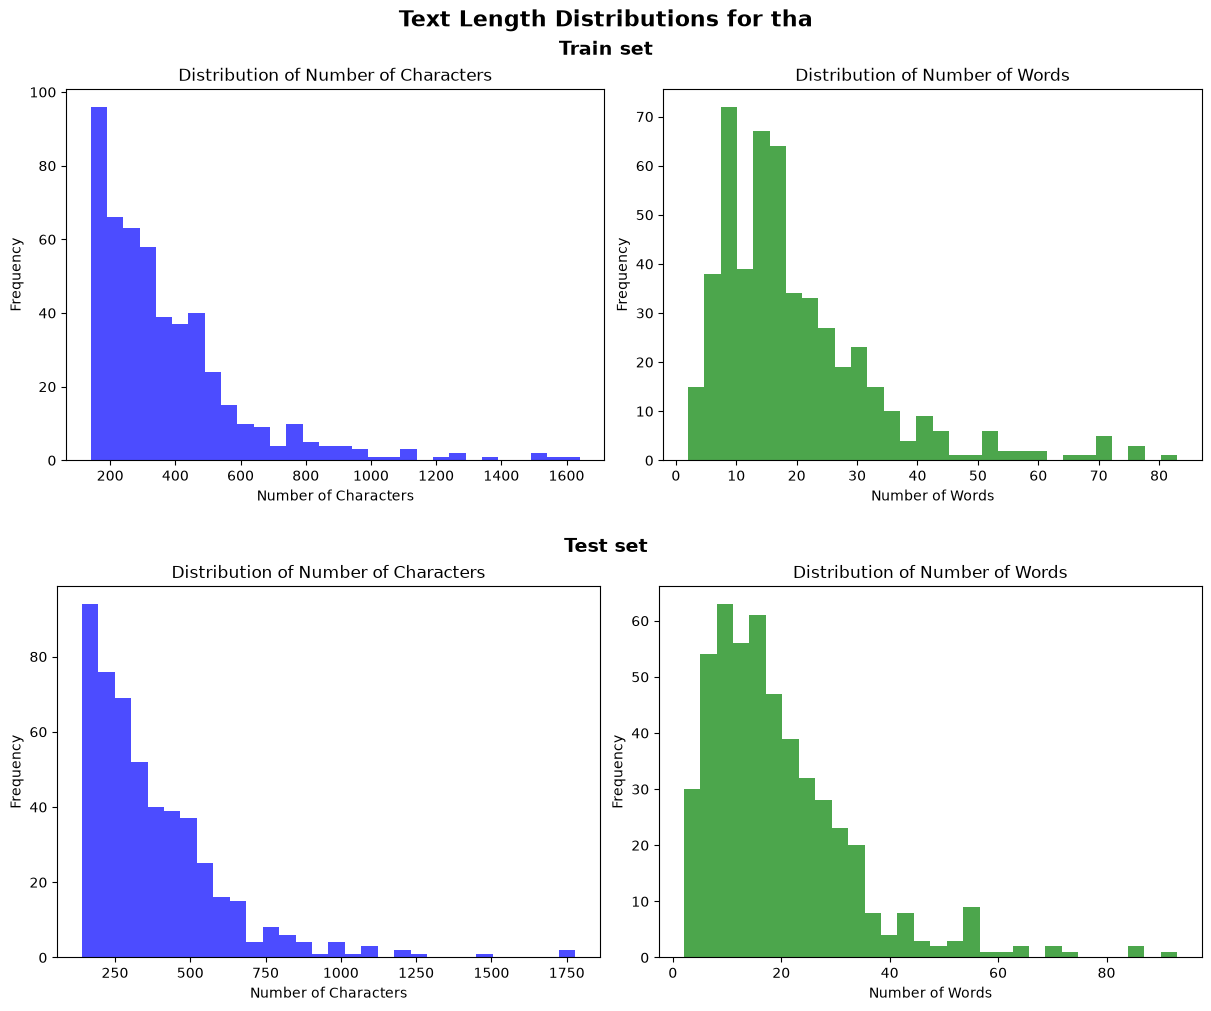

In [10]:
# plot the distribution of number of characters and number of words in the text column for a particular label
# first row: train_df, second row: test_df
import matplotlib.pyplot as plt

label = 'tha'
splits = {'train': train_df, 'test': test_df}

fig = plt.figure(figsize=(12, 10), layout='constrained')
fig.suptitle(f'Text Length Distributions for {label}', fontsize=16, fontweight='bold')
subfigs = fig.subfigures(2, 1, hspace=0.05)
for subfig, (split_name, df) in zip(subfigs, splits.items()):
    label_df = df[df['label'] == label]
    subfig.suptitle(f'{split_name.capitalize()} set', fontsize=14, fontweight='bold')
    axs = subfig.subplots(1, 2)

    axs[0].hist(label_df['text'].str.len(), bins=30, color='blue', alpha=0.7)
    axs[0].set_title('Distribution of Number of Characters')
    axs[0].set_xlabel('Number of Characters')
    axs[0].set_ylabel('Frequency')

    axs[1].hist(label_df['text'].str.split().str.len(), bins=30, color='green', alpha=0.7)
    axs[1].set_title('Distribution of Number of Words')
    axs[1].set_xlabel('Number of Words')
    axs[1].set_ylabel('Frequency')

plt.show()

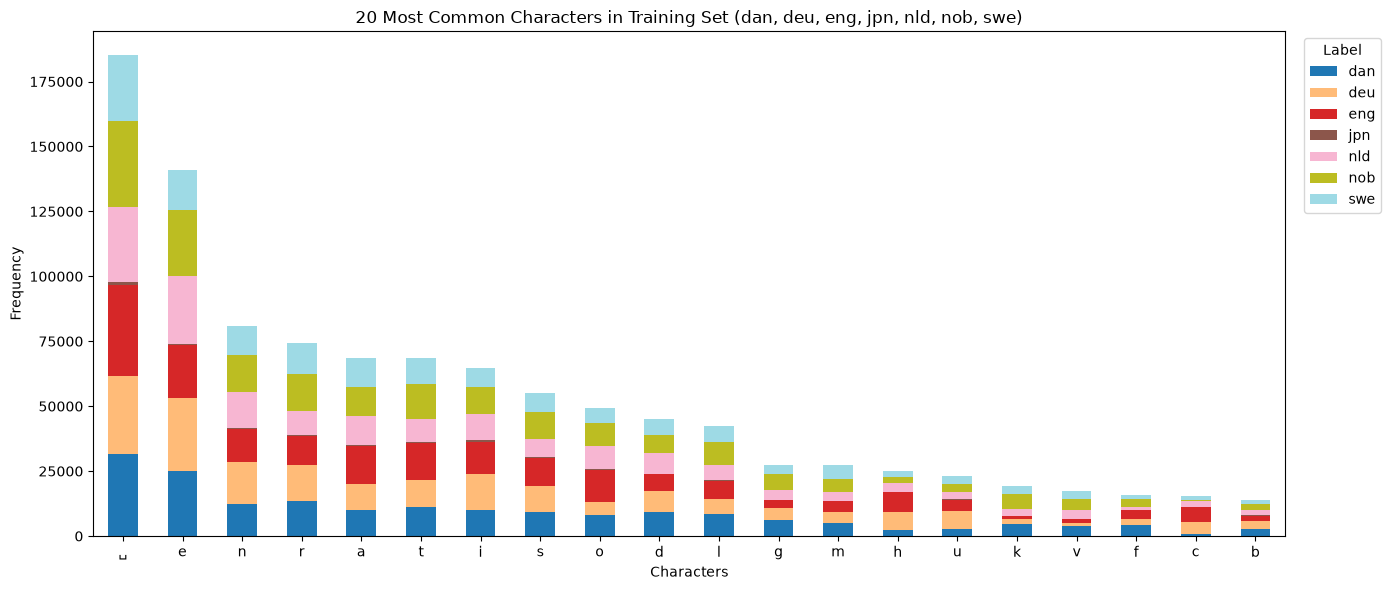

In [11]:
# look at the 20 most common characters across a set of languages,
# with each bar split by how much each language contributes to the count
from collections import Counter
import matplotlib.pyplot as plt

selected_labels = sorted(['eng', 'deu', 'nld', 'dan', 'swe', 'nob', 'jpn'])
subset_df = train_df[train_df['label'].isin(selected_labels)]

# Count the frequency of each character per label (rows: characters, columns: labels)
char_counts = pd.DataFrame({
    label: Counter(''.join(texts))
    for label, texts in subset_df.groupby('label')['text']
}).fillna(0).astype(int)

# Get the 20 most common characters over all selected labels
top_chars = char_counts.sum(axis=1).nlargest(20).index
top_counts = char_counts.loc[top_chars, selected_labels]
top_counts.index = top_counts.index.map(lambda c: '␣' if c == ' ' else c)  # make space visible

# Plot the distributions as stacked bars, one segment per label
ax = top_counts.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20', rot=0)
ax.set_title(f"20 Most Common Characters in Training Set ({', '.join(selected_labels)})")
ax.set_xlabel("Characters")
ax.set_ylabel("Frequency")
ax.legend(title='Label', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [12]:
# for each label, find top 10 most common characters and their counts
top_chars_per_label = {}
for label in labels:
    label_df = train_df[train_df['label'] == label]
    char_count = Counter(''.join(label_df['text']))
    top_chars_per_label[label] = char_count.most_common(50)

In [ ]:
# exclude the space character from the top characters per label
for label in top_chars_per_label:
    top_chars_per_label[label] = [(char, count) for char, count in top_chars_per_label[label] if char != ' ']
top_chars_per_label

{'est': [('a', 17012),
  ('i', 14054),
  ('e', 13793),
  ('s', 11857),
  ('t', 9558),
  ('l', 7816),
  ('n', 7154),
  ('u', 7109),
  ('o', 6503),
  ('k', 5850),
  ('r', 5138),
  ('d', 5078),
  ('m', 4487),
  ('v', 2909),
  ('g', 2553),
  ('j', 2193),
  ('p', 2109),
  ('h', 2065),
  ('.', 1981),
  (',', 1522),
  ('õ', 1362),
  ('ä', 1324),
  ('b', 1292),
  ('ü', 984),
  ('1', 848),
  ('0', 575),
  ('9', 551),
  ('2', 457),
  ('S', 432),
  ('K', 390),
  ('T', 390),
  ('A', 385),
  ('(', 352),
  (')', 352),
  ('P', 343),
  ('f', 340),
  ('-', 320),
  ('ö', 304),
  ('c', 282),
  ('L', 275),
  ('M', 264),
  ('E', 262),
  ('"', 255),
  ('3', 247),
  ('N', 246),
  ('8', 241),
  ('V', 239),
  ('4', 236),
  ('R', 233)],
 'swe': [('e', 15166),
  ('r', 11914),
  ('a', 11457),
  ('n', 11255),
  ('t', 9817),
  ('i', 7250),
  ('s', 7008),
  ('d', 6353),
  ('l', 6102),
  ('o', 5506),
  ('m', 5266),
  ('g', 3459),
  ('k', 3328),
  ('v', 3019),
  ('u', 3007),
  ('ä', 2663),
  ('h', 2276),
  ('.', 1935)

In [14]:
# for each pair of labels, count the common characters from char in (char, count)
# for example, if label1 has [('a', 10), ('b', 5), ('c', 2)] and label2 has [('b', 7), ('c', 3), ('d', 1)], the common characters are 'b' and 'c' this will count as 2
# then create a matrix of size (num_labels, num_labels) where each cell (i, j) contains the count of common characters between label i and label j
common_chars_matrix = pd.DataFrame(index=labels, columns=labels, dtype=int)
for i, label1 in enumerate(labels):
    chars1 = set(char for char, count in top_chars_per_label[label1])
    for j, label2 in enumerate(labels):
        chars2 = set(char for char, count in top_chars_per_label[label2])
        common_chars_matrix.loc[label1, label2] = len(chars1.intersection(chars2))

In [15]:
common_chars_matrix

,est,swe,mai,oci,tha,orm,lim,guj,pnb,zea,...,aym,tgk,ceb,xho,bpy,ell,lij,hau,mkd,ltz
est,49.0,39.0,2.0,36.0,3.0,34.0,37.0,11.0,9.0,36.0,...,36.0,14.0,38.0,39.0,4.0,11.0,34.0,35.0,13.0,36.0
swe,39.0,49.0,2.0,38.0,3.0,38.0,38.0,11.0,8.0,38.0,...,36.0,12.0,41.0,38.0,2.0,11.0,32.0,39.0,12.0,38.0
mai,2.0,2.0,49.0,2.0,1.0,2.0,2.0,2.0,0.0,2.0,...,2.0,2.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0
oci,36.0,38.0,2.0,49.0,3.0,39.0,37.0,11.0,8.0,35.0,...,39.0,14.0,37.0,40.0,4.0,11.0,39.0,37.0,12.0,37.0
tha,3.0,3.0,1.0,3.0,49.0,3.0,3.0,2.0,1.0,3.0,...,3.0,3.0,3.0,3.0,1.0,3.0,3.0,3.0,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ell,11.0,11.0,2.0,11.0,3.0,11.0,11.0,7.0,4.0,11.0,...,11.0,11.0,11.0,11.0,2.0,49.0,10.0,11.0,8.0,11.0
lij,34.0,32.0,2.0,39.0,3.0,35.0,36.0,11.0,5.0,33.0,...,34.0,13.0,30.0,37.0,4.0,10.0,49.0,32.0,10.0,33.0
hau,35.0,39.0,2.0,37.0,3.0,41.0,41.0,11.0,9.0,40.0,...,36.0,14.0,39.0,41.0,4.0,11.0,32.0,49.0,14.0,37.0
mkd,13.0,12.0,2.0,12.0,3.0,12.0,11.0,4.0,10.0,13.0,...,11.0,35.0,13.0,11.0,4.0,8.0,10.0,14.0,49.0,9.0


hierarchical clustering
1. col 0, 1	- An index from 0 to 234 is a single language, i.e. that row of matrix. An index of 235 or more is a cluster made in an earlier step
2. How far apart the two clusters were when they merged. With method='average', this is the average Euclidean distance between their members' rows. Smaller means more similar.
3. How many languages the new cluster contains.

In [79]:
# plot common_chars_matrix as a heatmap
# labels are reordered with hierarchical clustering so that languages sharing many characters (e.g. same script) end up next to each other
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list

# [cluster A, cluster B, distance, size].
linkage(matrix.values, method='average')

array([[184.        , 185.        ,   3.87298335,   2.        ],
       [191.        , 192.        ,   6.92820323,   2.        ],
       [160.        , 161.        ,   7.        ,   2.        ],
       [157.        , 158.        ,   7.48331477,   2.        ],
       [ 64.        ,  65.        ,   9.79795897,   2.        ],
       [ 41.        ,  42.        ,  11.09053651,   2.        ],
       [156.        , 238.        ,  11.23991923,   3.        ],
       [186.        , 187.        ,  11.87434209,   2.        ],
       [ 88.        ,  89.        ,  11.91637529,   2.        ],
       [209.        , 210.        ,  12.76714533,   2.        ],
       [163.        , 164.        ,  13.3041347 ,   2.        ],
       [159.        , 237.        ,  13.72387961,   3.        ],
       [ 40.        , 240.        ,  14.06204524,   3.        ],
       [ 37.        ,  38.        ,  14.14213562,   2.        ],
       [ 36.        , 248.        ,  14.17744688,   3.        ],
       [ 34.        ,  35

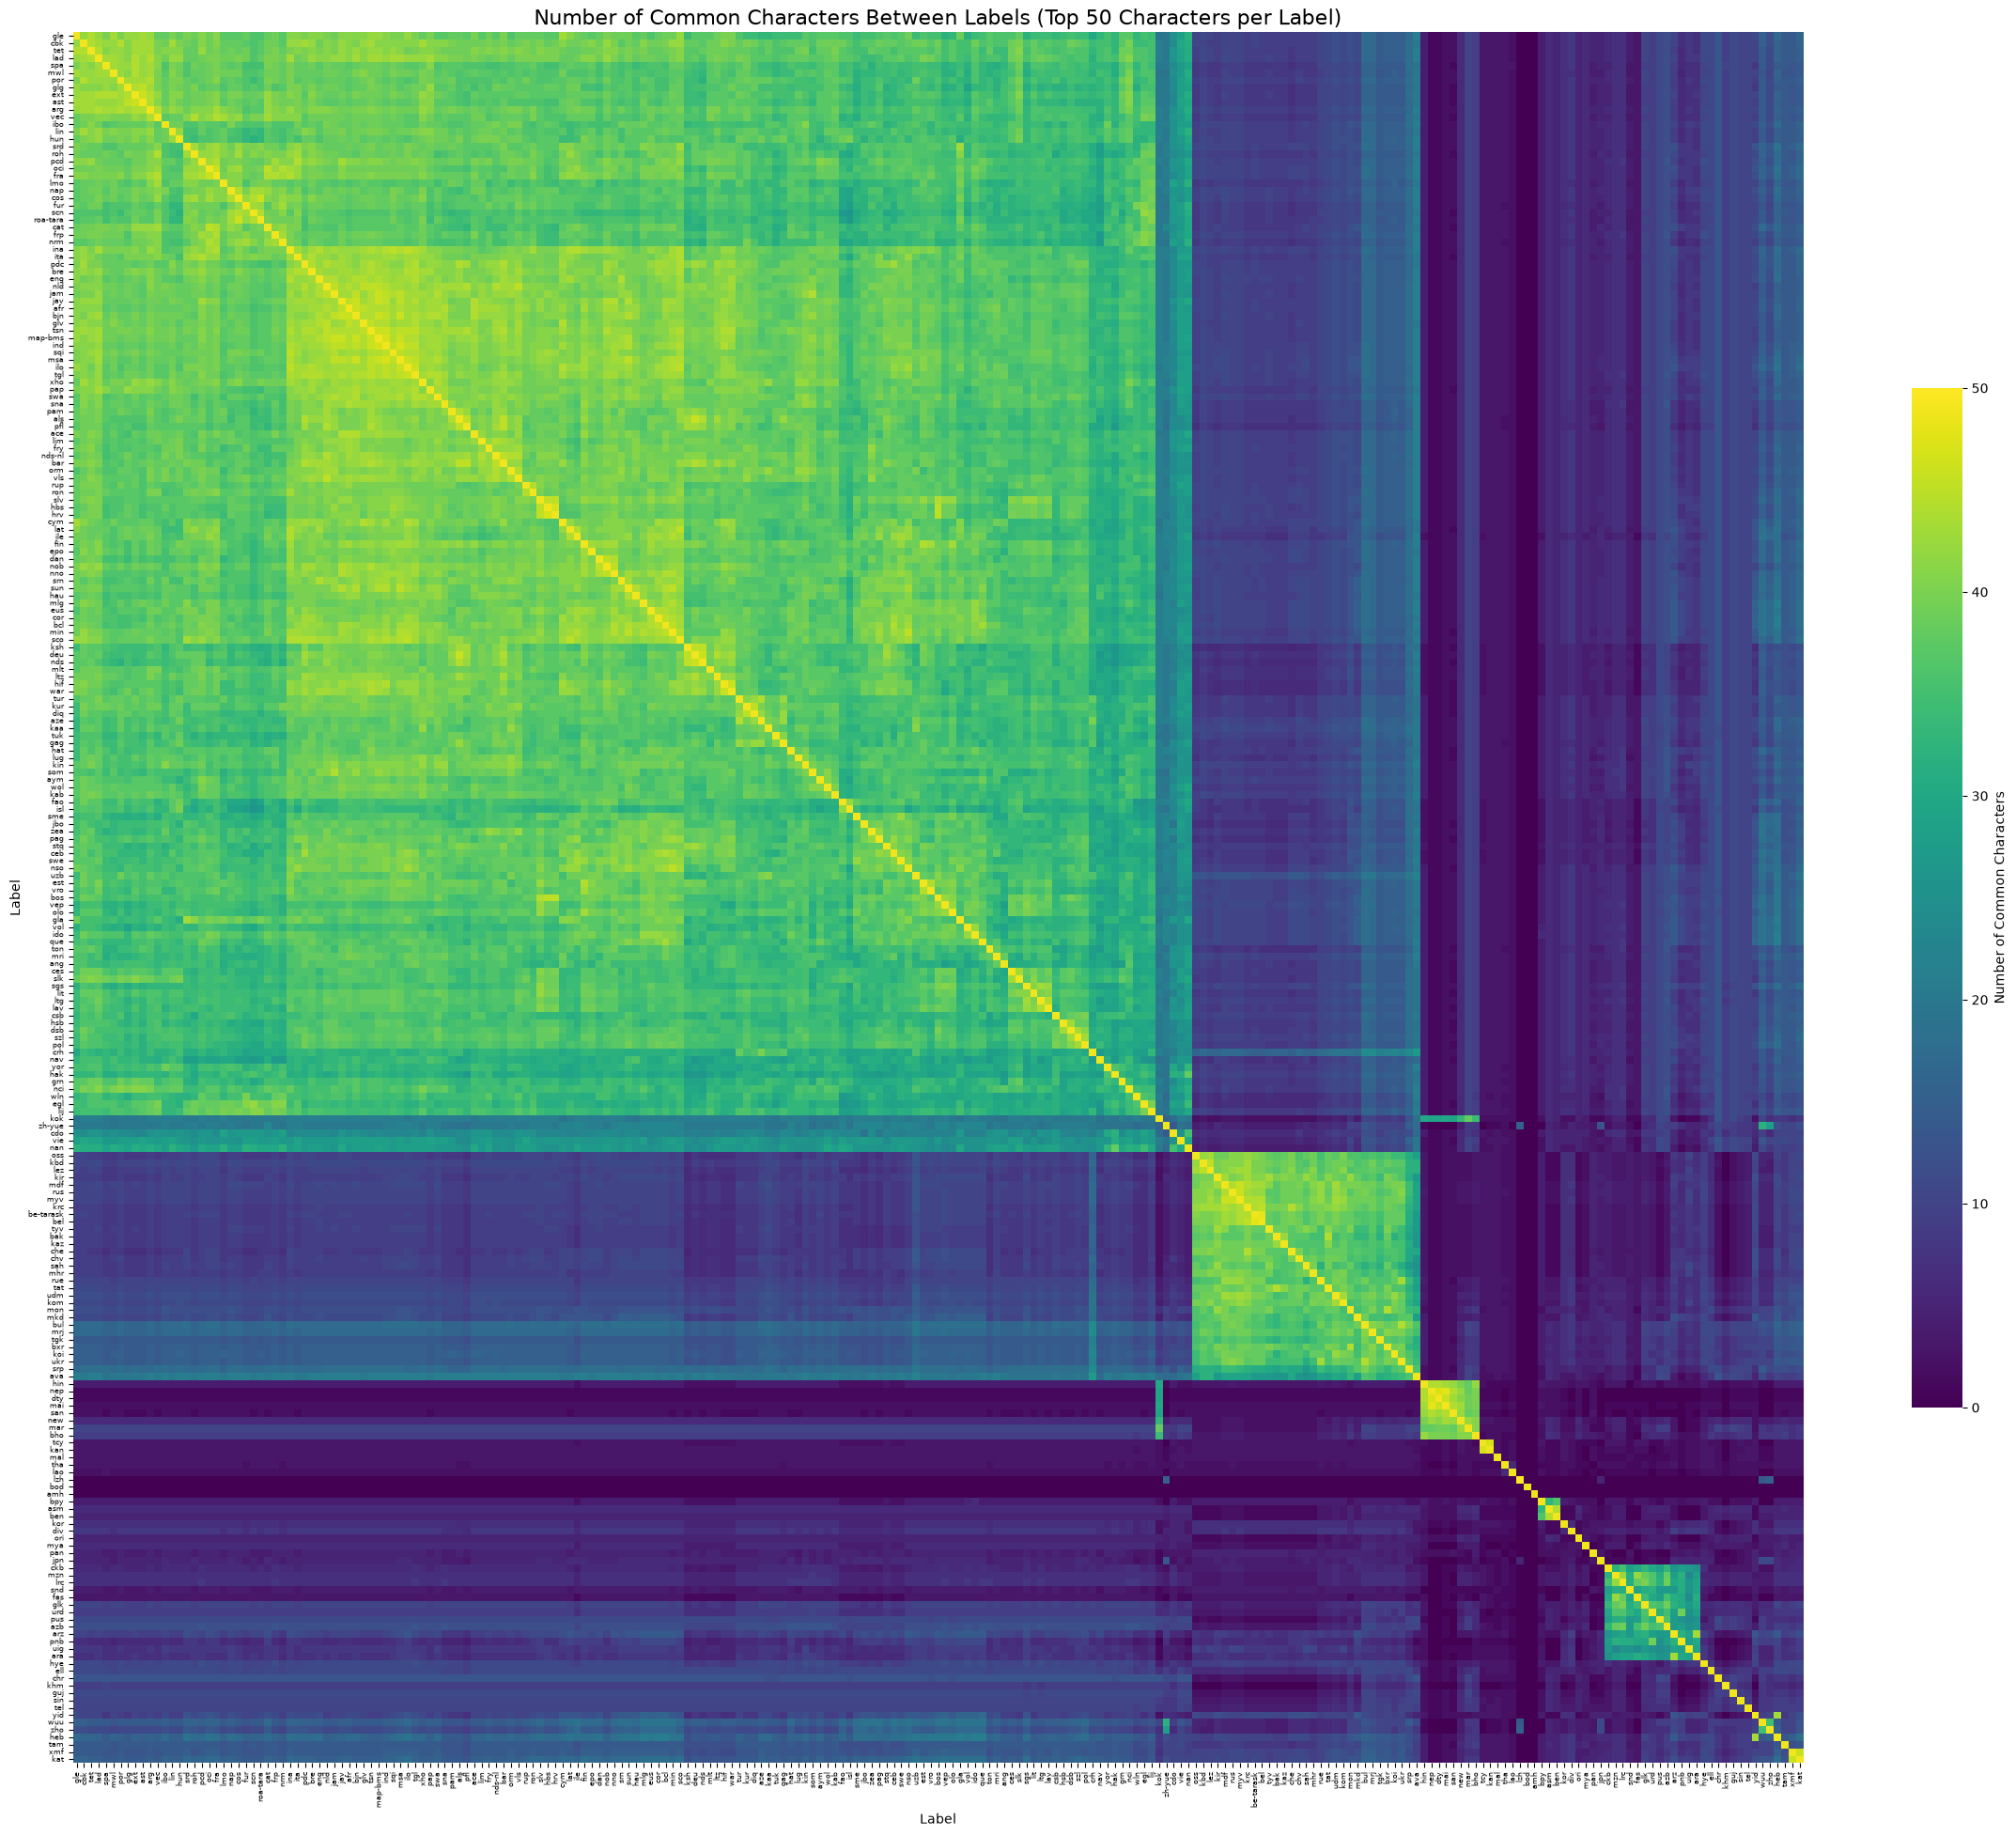

In [78]:
matrix = common_chars_matrix.astype(int)
# reorder the matrix using hierarchical clustering using the average linkage method
# first it starts with every language as its own cluster, then it merges the two closest clusters (i.e. languages sharing the most characters) into a new cluster, and repeats this process until all languages are in one cluster
order = matrix.index[leaves_list(linkage(matrix.values, method='average'))]
matrix = matrix.loc[order, order]

fig, ax = plt.subplots(figsize=(24, 22))
sns.heatmap(matrix, cmap='viridis', square=True, xticklabels=True, yticklabels=True,
            cbar_kws={'label': 'Number of Common Characters', 'shrink': 0.5}, ax=ax)
ax.set_title('Number of Common Characters Between Labels (Top 50 Characters per Label)', fontsize=16)
ax.set_xlabel('Label')
ax.set_ylabel('Label')
ax.tick_params(labelsize=6)
plt.tight_layout()
plt.show()

In [ ]:
# identify the blocks in the heatmap
# two labels are linked if they share at least `threshold` of their top characters,
# and each group is a set of labels connected through such links (connected components of the graph)
from scipy.sparse.csgraph import connected_components

threshold = 30
matrix = common_chars_matrix.astype(int)

# first create adjacency matrix where an edge exists between two labels if they share at least `threshold` characters
adjacency_matrix = (matrix.values >= threshold).astype(int)

# find connected components of the graph if there's a link between two labels
n_groups, group_ids = connected_components(adjacency_matrix, directed=False)
groups = sorted(
    (sorted(matrix.index[group_ids == g]) for g in range(n_groups)),
    key=len, reverse=True,
)

big_block = groups[0]                                       # 1. the big bright block
smaller_blocks = [g for g in groups[1:] if len(g) >= 5]     # 2. the smaller blocks
tiny_blocks = [g for g in groups[1:] if 1 < len(g) < 5]     #    (pairs/triples, barely visible in the heatmap)
own_chars = sorted(g[0] for g in groups if len(g) == 1)     # 3. labels that only share characters with themselves

print(f"1. Big block ({len(big_block)} labels):\n{big_block}\n")
print("2. Smaller blocks:")
for g in smaller_blocks:
    print(f"   ({len(g)} labels) {g}")
print("   Tiny blocks:")
for g in tiny_blocks:
    print(f"   ({len(g)} labels) {g}")
print(f"\n3. Own characters ({len(own_chars)} labels):\n{own_chars}")

1. Big block (150 labels):
['ace', 'afr', 'als', 'ang', 'arg', 'ast', 'aym', 'aze', 'bar', 'bcl', 'bjn', 'bos', 'bre', 'cat', 'cbk', 'cdo', 'ceb', 'ces', 'cor', 'cos', 'crh', 'csb', 'cym', 'dan', 'deu', 'diq', 'dsb', 'egl', 'eng', 'epo', 'est', 'eus', 'ext', 'fao', 'fin', 'fra', 'frp', 'fry', 'fur', 'gag', 'gla', 'gle', 'glg', 'glv', 'grn', 'hak', 'hat', 'hau', 'hbs', 'hif', 'hrv', 'hsb', 'hun', 'ibo', 'ido', 'ile', 'ilo', 'ina', 'ind', 'isl', 'ita', 'jam', 'jav', 'jbo', 'kaa', 'kab', 'kin', 'ksh', 'kur', 'lad', 'lat', 'lav', 'lij', 'lim', 'lin', 'lit', 'lmo', 'ltg', 'ltz', 'lug', 'map-bms', 'min', 'mlg', 'mlt', 'mri', 'msa', 'mwl', 'nan', 'nap', 'nav', 'nci', 'nds', 'nds-nl', 'nld', 'nno', 'nob', 'nrm', 'nso', 'oci', 'olo', 'orm', 'pag', 'pam', 'pap', 'pcd', 'pdc', 'pfl', 'pol', 'por', 'que', 'roa-tara', 'roh', 'ron', 'rup', 'scn', 'sco', 'sgs', 'slk', 'slv', 'sme', 'sna', 'som', 'spa', 'sqi', 'srd', 'srn', 'stq', 'sun', 'swa', 'swe', 'szl', 'tet', 'tgl', 'ton', 'tsn', 'tuk', 'tur', '

1. Big block, Latin script (150 labels): ace, afr, als, … eng, deu, nld, dan, swe, nob, … The cell prints the full list.
2. Three smaller blocks:
    - Cyrillic (31): ava, bak, be-tarask, bel, bul, bxr, che, chv, kaz, kbd, kir, koi, kom, krc, lez, mdf, mhr, mkd, mon, mrj, myv, oss, rue, rus, sah, srp, tat, tgk, tyv, udm, ukr
    - Arabic script (12): ara, arz, azb, ckb, fas, glk, lrc, mzn, pnb, pus, snd, urd
    - Devanagari (9): bho, dty, hin, kok, mai, mar, nep, new, san
3. Tiny blocks:
    - Chinese: wuu, zh-yue, zho
    - Bengali script: asm, ben, bpy
    - Hebrew script: heb, yid
    - Kannada script: kan, tcy
    - Georgian script: kat, xmf
4. Own characters (21): amh, bod, chr, div, ell, guj, hye, jpn, khm, kor, lao, lzh, mal, mya, ori, pan, sin, tam, tel, tha, uig

rus, ara, hin, zho, asm, heb, kan, kat, kor, tha, 

#### Evidence: closely related languages

In [17]:
# closely related languages: compare character trigram profiles of every pair of labels
# each label becomes one vector of trigram frequencies (all its training texts joined together),
# and cosine similarity close to 1 means the two labels use almost the same trigrams in the same proportions
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

label_texts = train_df.groupby('label')['text'].apply(' '.join)
trigram_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(3, 3), use_idf=False, max_features=200_000)
trigram_profiles = trigram_vectorizer.fit_transform(label_texts)
trigram_similarity = pd.DataFrame(cosine_similarity(trigram_profiles), index=label_texts.index, columns=label_texts.index)

# keep each pair once (upper triangle without the diagonal) and list the most similar pairs
upper = np.triu(np.ones(trigram_similarity.shape, dtype=bool), k=1)
similar_pairs = (
    trigram_similarity.where(upper).stack()
    .rename_axis(['label1', 'label2']).reset_index(name='cosine_similarity')
    .sort_values('cosine_similarity', ascending=False)
)
similar_pairs.head(20)

,label1,label2,cosine_similarity
17232,hbs,hrv,0.981783
20347,ind,msa,0.980292
5478,bos,hbs,0.976227
5482,bos,hrv,0.976006
4013,be-tarask,bel,0.937535
10022,dan,nob,0.924226
7005,cbk,spa,0.919270
2305,ast,spa,0.916766
15444,glg,por,0.916689
20336,ind,map-bms,0.915780


#### Evidence: same text under different labels

In [ ]:
# same text under different labels: texts that appear more than once with conflicting labels
full_df = pd.concat([train_df.assign(split='train'), test_df.assign(split='test')])
labels_per_text = full_df.groupby('text')['label'].unique()
conflicting = labels_per_text[labels_per_text.str.len() > 1]

print(f"{len(conflicting)} distinct texts appear with more than one label "
      f"({full_df['text'].isin(conflicting.index).sum()} rows in train + test)\n")

# which label combinations conflict most often
conflict_pairs = conflicting.apply(lambda l: ' / '.join(sorted(l))).value_counts()
print(conflict_pairs.head(10).to_string(), '\n')

# a few examples
pd.DataFrame({'labels': conflicting.apply(sorted), 'text': conflicting.index.str[:100]}).reset_index(drop=True).head(5)

130 distinct texts appear with more than one label (524 rows in train + test)

label
ava / pcd        82
dty / nep        13
ava / lez         8
ace / map-bms     3
lrc / snd         2
pdc / pfl         2
kan / mai         2
dsb / hsb         2
ina / srd         2
hau / wol         1 



,labels,text
0,"[hau, wol]","""Esperanto""; FUNDAMENTO DE ESPERANTO Antaŭparo..."
1,"[lrc, snd]",'باسكن روبنز هو كريم كريم المؤسسة الأمريكية ال...
2,"[ava, pcd]",(Apologies if this message isn't in your langu...
3,"[ava, pcd]",(Apologies if this message isn't in your langu...
4,"[ava, pcd]",(Apologies if this message isn't in your langu...


#### Evidence: overlap between train and test

In [19]:
# overlap between train and test: exact duplicate texts within each split and across the two splits
train_texts = set(train_df['text'])
test_in_train = test_df['text'].isin(train_texts)

print(f"Duplicate rows within train: {train_df['text'].duplicated().sum()}")
print(f"Duplicate rows within test:  {test_df['text'].duplicated().sum()}")
print(f"Test rows whose text also appears in train: {test_in_train.sum()} of {len(test_df)} "
      f"({test_in_train.mean():.1%})\n")

# per label: how many of the 500 test examples were already seen in training
overlap_per_label = (
    test_df.assign(in_train=test_in_train)
    .groupby('label')['in_train'].agg(overlapping='sum', share='mean')
    .sort_values('overlapping', ascending=False)
)
overlap_per_label[overlap_per_label['overlapping'] > 0].head(15)

Duplicate rows within train: 2681
Duplicate rows within test:  2720
Test rows whose text also appears in train: 3147 of 117500 (2.7%)



,overlapping,share
label,,
che,449,0.898
hat,407,0.814
new,324,0.648
pam,290,0.580
min,160,0.320
srn,136,0.272
hsb,121,0.242
sun,112,0.224
bak,100,0.200


#### Evidence: train vs test length distributions (KS test per language)

In [20]:
# statistical test: does each language have the same length distribution in train and test?
# two-sample Kolmogorov-Smirnov test per label, for character count and word count (split on spaces)
# H0: train and test lengths come from the same distribution
from scipy.stats import ks_2samp

length_measures = {
    'chars': lambda s: s.str.len(),
    'words': lambda s: s.str.split().str.len(),
}

rows = []
for label in sorted(labels):
    train_text = train_df.loc[train_df['label'] == label, 'text']
    test_text = test_df.loc[test_df['label'] == label, 'text']
    row = {'label': label}
    for name, measure in length_measures.items():
        result = ks_2samp(measure(train_text), measure(test_text))
        row[f'{name}_ks'] = result.statistic
        row[f'{name}_p'] = result.pvalue
    rows.append(row)
ks_results = pd.DataFrame(rows).set_index('label')

# with 235 tests, ~5% will have p < 0.05 by chance alone, so also apply a Bonferroni correction
alpha = 0.05
bonferroni_alpha = alpha / len(ks_results)
for name in length_measures:
    p = ks_results[f'{name}_p']
    print(f"{name}: p < {alpha}: {(p < alpha).sum()} labels (expected by chance: ~{alpha * len(p):.0f}), "
          f"p < {bonferroni_alpha:.1e} (Bonferroni): {(p < bonferroni_alpha).sum()} labels")

ks_results.sort_values('chars_p').head(10)

chars: p < 0.05: 7 labels (expected by chance: ~12), p < 2.1e-04 (Bonferroni): 0 labels
words: p < 0.05: 6 labels (expected by chance: ~12), p < 2.1e-04 (Bonferroni): 0 labels


,chars_ks,chars_p,words_ks,words_p
label,,,,
pap,0.104,0.008922,0.106,0.007228
diq,0.100,0.013431,0.122,0.001159
bel,0.094,0.024066,0.086,0.049503
slk,0.094,0.024066,0.086,0.049503
nds,0.090,0.034795,0.084,0.058689
ksh,0.086,0.049503,0.046,0.665922
bxr,0.086,0.049503,0.080,0.081502
sah,0.084,0.058689,0.080,0.081502
som,0.084,0.058689,0.088,0.041586


#### Evidence: train vs test character frequency distributions (permutation test)

In [21]:
# statistical test: does each language use characters in the same proportions in train and test?
# per label, count every character occurrence in train and in test, e.g. eng: {'e': 20353, 't': 14931, ...}, and compare the two distributions
#
# Jensen-Shannon distance (JSD) between the two distributions + a permutation test
#    -> shuffle whole texts between train and test (keeping 500/500), recompute the JSD each time, and check
#       how often a random split is at least as different as the real one; this respects that characters
#       come in texts and are not independent
#
# note: why not a chi-square test of homogeneity on the (2 x characters) count table?
#    -> it treats every single character as an independent observation, i.e. it assumes ~150,000 independent
#       characters per split, while what we actually have is 500 independent texts per split (characters within
#       one text are strongly related). With that many "observations" even tiny, meaningless differences become
#       significant: it rejects H0 for all 235 labels. Using ratios instead of counts does not fix it either,
#       since the chi-square statistic scales with the counts and the p-value would depend on an arbitrary scale.
from sklearn.feature_extraction.text import CountVectorizer
from scipy.special import rel_entr

rng = np.random.default_rng(42)
# the smallest possible permutation p-value is 1 / (n_permutations + 1),
# so we need more than 235 / 0.05 = 4700 permutations to be able to pass the Bonferroni threshold
n_permutations = 5000

def jensen_shannon_distance(a, b):
    # row-wise JSD (base 2, between 0 and 1) between count vectors a and b
    a = a / a.sum(axis=-1, keepdims=True)
    b = b / b.sum(axis=-1, keepdims=True)
    m = (a + b) / 2
    return np.sqrt((rel_entr(a, m).sum(axis=-1) + rel_entr(b, m).sum(axis=-1)) / 2 / np.log(2))

rows = []
for label in sorted(labels):
    label_df = pd.concat([train_df[train_df['label'] == label].assign(is_train=True),
                          test_df[test_df['label'] == label].assign(is_train=False)])
    # rows: texts, columns: characters, values: how often the character occurs in the text
    X = CountVectorizer(analyzer='char', lowercase=False).fit_transform(label_df['text'])
    is_train = label_df['is_train'].to_numpy()
    total_counts = np.asarray(X.sum(axis=0)).ravel()

    train_counts = X.T @ is_train.astype(float)
    test_counts = total_counts - train_counts
    observed_jsd = jensen_shannon_distance(train_counts, test_counts)

    # all permutations at once: each row of `masks` is a random train/test assignment of the texts
    masks = np.array([rng.permutation(is_train) for _ in range(n_permutations)], dtype=float)
    permuted_train_counts = (X.T @ masks.T).T
    permuted_jsd = jensen_shannon_distance(permuted_train_counts, total_counts - permuted_train_counts)

    rows.append({
        'label': label,
        'jsd': observed_jsd,
        'jsd_permuted_mean': permuted_jsd.mean(),
        'jsd_p': (1 + np.sum(permuted_jsd >= observed_jsd)) / (1 + n_permutations),
    })
char_dist_results = pd.DataFrame(rows).set_index('label')

p = char_dist_results['jsd_p']
print(f"jsd_p: p < {alpha}: {(p < alpha).sum()} labels (expected by chance: ~{alpha * len(p):.0f}), "
      f"p < {bonferroni_alpha:.1e} (Bonferroni): {(p < bonferroni_alpha).sum()} labels")

char_dist_results.sort_values('jsd_p').head(10)

jsd_p: p < 0.05: 10 labels (expected by chance: ~12), p < 2.1e-04 (Bonferroni): 0 labels


,jsd,jsd_permuted_mean,jsd_p
label,,,
glk,0.079394,0.044765,0.004799
nno,0.039477,0.034283,0.006599
fry,0.031770,0.027561,0.006999
zho,0.165164,0.156607,0.010398
kan,0.045194,0.029923,0.017996
ita,0.030372,0.026827,0.020196
rus,0.037976,0.029002,0.021196
cat,0.033084,0.028961,0.033393
lug,0.034056,0.027801,0.040792


### 1.2 Data preparation

Get a subset of the train/test data that includes 20 languages.
Include English, German, Dutch, Danish, Swedish, Norwegian, and Japanese, plus 13 additional languages of your choice based on the items in the list of labels.

In [22]:
# TODO: Create your train/test subsets of languages
selected_labels = sorted(['eng', 'deu', 'nld', 'dan', 'swe', 'nob', 'jpn'])
additional_labels = sorted(['fra', 'spa', 'ita', 'rus', 'ara', 'hin', 'zho', 'asm', 'heb', 'kan', 'kor', 'tha', 'vie'])
all_labels = sorted(selected_labels + additional_labels)

from sklearn.model_selection import train_test_split
# shuffle the train_df and test_df to ensure randomness and use 80% of the data for training and 20% for testing
train_test_df = pd.concat([train_df, test_df]).sample(frac=1, random_state=42).reset_index(drop=True)
train_test_df = train_test_df[train_test_df['label'].isin(all_labels)].drop_duplicates(subset=['text'])
x_train, x_test, y_train, y_test = train_test_split(
    train_test_df['text'], train_test_df['label'],
    test_size=0.2, stratify=train_test_df['label'], random_state=42)

In [45]:
print('num x_train:', len(x_train))
print('num x_test:', len(x_test))

num x_train: 15984
num x_test: 3996


In [23]:
# TODO: With the following code, we wanted to ENCODE the labels, however, our cat was walking on the keyboard and some of it got changed. Can you fix it?
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder().fit(y_train)
y_train, y_test = label_encoder.transform(y_train), label_encoder.transform(y_test)
print(label_encoder.classes_)
print(y_train)
print(y_test)

['ara' 'asm' 'dan' 'deu' 'eng' 'fra' 'heb' 'hin' 'ita' 'jpn' 'kan' 'kor'
 'nld' 'nob' 'rus' 'spa' 'swe' 'tha' 'vie' 'zho']
[2 2 5 ... 6 9 2]
[19 12 11 ...  8 18 14]


### 2.1 Build a LogisticRegression classifier

To start with, we're going to build a very simple LogisticRegression classifier.
Use a `Pipeline` to chain togther a `CountVectorizer` and a `LogisticRegression` estimator. Then perform a 5-fold cross validation and report the scores of this model as a baseline.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# TODO: Define a very basic pipeline using a CountVectorizer and a LogisticRegression classifier
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()), # word-level tokenization with default settings
    ('classifier', LogisticRegression())
])

# TODO: Run a cross validation to estimate the model's expected performance
# perform 5-fold cross-validation on the training set and print the mean accuracy
cv_scores = cross_val_score(pipeline, x_train, y_train, cv=5, scoring='accuracy')
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")


Mean CV accuracy: 0.9436


In [27]:
cv_scores.std()

np.float64(0.004601406288006003)

In [ ]:
## using character n-grams instead of word-level tokenization, and limit the number of features to 100,000
pipeline = Pipeline([
    ('vectorizer', CountVectorizer(analyzer='char_wb', ngram_range=(2,3), max_features=100_000)),
    ('classifier', LogisticRegression())
])

cv_scores = cross_val_score(pipeline, x_train, y_train, cv=5, scoring='accuracy')
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"CV accuracy std: {cv_scores.std():.4f}")

Mean CV accuracy: 0.9864
CV accuracy std: 0.0014


In [ ]:
## using character but cross space (not as good)
pipeline = Pipeline([
    ('vectorizer', CountVectorizer(analyzer='char', ngram_range=(2,3), max_features=100_000)),
    ('classifier', LogisticRegression())
])

cv_scores = cross_val_score(pipeline, x_train, y_train, cv=3, scoring='accuracy')
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"CV accuracy std: {cv_scores.std():.4f}")

Mean CV accuracy: 0.9847
CV accuracy std: 0.0011


In [32]:
pipeline = Pipeline([
    ('vectorizer', CountVectorizer(analyzer='char_wb', ngram_range=(2,4), max_features=100_000)),
    ('tfidf', TfidfTransformer()),
    ('classifier', LogisticRegression())
])

cv_scores = cross_val_score(pipeline, x_train, y_train, cv=5, scoring='accuracy')
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"CV accuracy std: {cv_scores.std():.4f}")

Mean CV accuracy: 0.9861
CV accuracy std: 0.0017



### 2.2 Feature Engineering

So far, we've only considered the basic `CountVectorizer` at the word level to encode our input texts for our model.

Your task is to apply some text preprocessing and engineer some more informative features.

To do this, think about what other features might be relevant for determining the language of an input text.

Define a custom set of feature extractors and implement the necessary preprocessing steps to extract these features from strings.

Then initialise a processing pipeline that converts your input data into features that the model can take as input.

☝ Note, this step can be as involved as your heart desires, there is only one minimal requirement: you must use something more than the base `CountVectorizer`. We recommend that you take a look at the [`BaseEstimator`](https://scikit-learn.org/stable/modules/generated/sklearn.base.BaseEstimator.html) and [`TransformerMixin`](https://scikit-learn.org/stable/modules/generated/sklearn.base.TransformerMixin.html#transformermixin) classes from `sk-learn`, as these can be helpful for defining custom transformers.


In [33]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler

def report(name, pipeline):
    scores = cross_val_score(pipeline, x_train, y_train, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

In [39]:
pipeline_char = Pipeline([
    ('vect', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 3), sublinear_tf=True, max_features=100_000)),
    ('reg', LogisticRegression()),
])
report('char_wb (2,3), min_df=0.5%, tf-idf', pipeline_char)

char_wb (2,3), min_df=0.5%, tf-idf: 0.9859 ± 0.0019


In [40]:
pipeline_word_char = Pipeline([
    ('vect', FeatureUnion([
        ('word', TfidfVectorizer(analyzer='word', sublinear_tf=True, max_features=50_000)),
        ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 3), sublinear_tf=True, max_features=50_000)),
    ])),
    ('reg', LogisticRegression()),
])
report('word + char_wb', pipeline_word_char)

word + char_wb: 0.9874 ± 0.0015


In [41]:
import re

def clean_text(text):
    text = re.sub(r'https?://\S+', ' ', text)   # URLs
    text = re.sub(r'\d+', ' ', text)            # numbers
    return re.sub(r'\s+', ' ', text).strip()    # collapse whitespace

pipeline_clean = Pipeline([
    ('vect', FeatureUnion([
        ('word', TfidfVectorizer(analyzer='word', sublinear_tf=True, preprocessor=clean_text, max_features=50_000)),
        ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 3), sublinear_tf=True, preprocessor=clean_text, max_features=50_000)),
    ])),
    ('reg', LogisticRegression()),
])
report('cleaned char_wb', pipeline_clean)

cleaned char_wb: 0.9877 ± 0.0014


In [43]:
import unicodedata
from sklearn.base import BaseEstimator, TransformerMixin

class TextStats(BaseEstimator, TransformerMixin):
    """Hand-crafted statistics about how a text is written."""
    feature_names = ['avg_word_len', 'space_ratio', 'upper_ratio', 'digit_ratio', 'punct_ratio', 'non_ascii_ratio']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        rows = []
        for text in X:
            n = max(len(text), 1)
            words = text.split()
            rows.append([
                np.mean([len(w) for w in words]) if words else 0,
                text.count(' ') / n,
                sum(c.isupper() for c in text) / n,
                sum(c.isdigit() for c in text) / n,
                sum(unicodedata.category(c).startswith('P') for c in text) / n,
                sum(ord(c) > 127 for c in text) / n,
            ])
        return np.array(rows)

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names)

In [44]:
pipeline_full = Pipeline([
    ('vect', FeatureUnion([
        ('word', TfidfVectorizer(analyzer='word', sublinear_tf=True, preprocessor=clean_text, max_features=50_000)),
        ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 3), sublinear_tf=True, preprocessor=clean_text, max_features=50_000)),
        ('stats', Pipeline([('extract', TextStats()), ('scale', StandardScaler())])),
    ])),
    ('reg', LogisticRegression()),
])
report('char_wb + stats', pipeline_full)

char_wb + stats: 0.9870 ± 0.0012


In [46]:
# number of features produced by each pipeline (only the feature extraction step, fitted on the training set)
from sklearn.base import clone

pipelines = {
    'char_wb': pipeline_char,
    'word + char_wb': pipeline_word_char,
    'cleaned word + char_wb': pipeline_clean,
    'cleaned word + char_wb + stats': pipeline_full,
}

feature_counts = {}
for name, pipe in pipelines.items():
    vect = clone(pipe.named_steps['vect']).fit(x_train)
    if isinstance(vect, FeatureUnion):
        # one count per block of the union, e.g. word / char / stats
        blocks = {block: len(transformer.get_feature_names_out()) for block, transformer in vect.transformer_list}
    else:
        blocks = {'char': len(vect.get_feature_names_out())}
    feature_counts[name] = {**blocks, 'total': sum(blocks.values())}

pd.DataFrame(feature_counts).T.fillna(0).astype(int)

,char,total,word,stats
char_wb,100000,100000,0,0
word + char_wb,50000,100000,50000,0
cleaned word + char_wb,50000,100000,50000,0
cleaned word + char_wb + stats,50000,100006,50000,6


In [47]:
# examples the model gets wrong, using 5-fold cross-validated predictions on the training set
# (each text is predicted by a model that did not see it during training, so the test set stays untouched)
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(pipeline_full, x_train, y_train, cv=5)
errors = pd.DataFrame({
    'true': label_encoder.inverse_transform(y_train),
    'predicted': label_encoder.inverse_transform(y_pred),
    'text': x_train.to_numpy(),
})
errors = errors[errors['true'] != errors['predicted']]
print(f"{len(errors)} of {len(x_train)} training texts misclassified ({len(errors) / len(x_train):.1%})\n")

# which confusions happen most often
print(errors.groupby(['true', 'predicted']).size().sort_values(ascending=False).head(10).to_string(), '\n')

# a few examples (text truncated to 200 characters)
with pd.option_context('display.max_colwidth', 200):
    display(errors.sample(10, random_state=42).assign(text=lambda d: d['text'].str[:200]))

208 of 15984 training texts misclassified (1.3%)

true  predicted
asm   eng          25
hin   eng          12
dan   deu          11
      nob           8
nob   eng           8
tha   eng           8
vie   eng           7
zho   eng           7
kor   zho           6
spa   eng           5 



,true,predicted,text
12204,kor,eng,"^ Hwang SW et al, Direct activation of capsaicin receptors by products of lipoxygenases: Endogenous capsaicin-like substances. Proc Natl Acad Sci USA (2000)."
1171,nob,eng,"Sabra, A. I., ed. The Optics of Ibn al-Haytham, Books I-II-III: On Direct Vision. The Arabic text, edited and with Introduction, Arabic-Latin Glossaries and Concordance Tables, Kuwait: National Co..."
5073,nld,eng,"The Damascus Chronicle of the Crusaders, extracted and translated from the Chronicle of Ibn al-Qalanisi. Uitgegeven en in het Engels vertaald door H.A.R. Gibb. London, 1932."
7131,deu,eng,"Edward Duyker: A French Garden in Tasmania. The Legacy of Félix Delahaye (1767—1829). Explorations, December 2004 (issued October 2005), S. 3–18."
12410,asm,eng,"This will be the longest and the most expensive general election in the history of the country, with the Election Commission of India estimating that the election will cost the exchequer 35 billio..."
656,dan,deu,"Alvise da Mosto, L'ARCHIVIO DI STATO DI VENEZIA. INDICE GENERALE, STORICO, DESCRITTIVO ED ANALITICO (PDF, 796 kB eller i HTML-Format) – overbliksværk over samlingerne i statsarkivet i Venedig, og ..."
7306,zho,eng,"Dorf, Matthew, After Barak win, AIPAC reverses opposition to a Palestinian state, The Jewish News Weekly of Northern California, May 28, 1999. Accessed March 27, 2006"
10358,tha,eng,"Titsingh, I. (1822). Illustrations of Japan; consisting of Private Memoirs and Anecdotes of the reigning dynasty of The Djogouns, or Sovereigns of Japan. London: Ackerman."
1220,kor,zho,佛告舍利弗：「此鴿除諸聲聞、辟支佛所知齊限，復於恒河沙等大劫中常作鴿身，罪訖得出。輪轉五道中，後得爲人，經五百世中，乃得利根。是時有佛，度無量阿僧祇眾生，然後入無餘涅槃。遺法在世，是人作五戒優婆塞，從比丘聞讚佛功德，於是初發心，願欲作佛。然後於三阿僧祇劫，行六波羅蜜，十地具足，得作佛，度無量眾生已而入無餘涅槃。」 是時，舍利弗向佛懺悔，白佛言：「我於一鳥，尚不能知其本末，何況諸法？我若知佛...
11263,jpn,kor,"(a, b, c, d ∈ Z, b ≠ 0, d ≠ 0) によって定めると、関係 ∼ は同値関係となる。商集合 E/∼ を改めて Q と記して、Q における対 (a, b) の属する同値類を a/b と記すことにすると、このような表記は一意的ではなく、異なる代表元 (c, d) について"


there are for sure many examples that are labeled wrongly
- This is not 'kor' 彼以聞慧。觀諸畜生種類差別。三十四億。隨心自在。生於五道。於五道中。畜生種類。其數最多。種種相貌。種種色類。行食不同。群飛各異。憎愛違順。伴行雙隻。同生共遊。所謂飛禽。及諸走獸。烏鵲鵝鴈。鴻鳥眾類。異群別遊。不相怨害。狐狗野干等。互相憎嫉。烏與角鴟。馬及水牛。蚖蛇鼬等。共相殘害。形相不同。行食各異。以何業故。種種形相行食各異。彼以聞慧。觀是眾生。爲種種心之所役使。作種種業。入種種道。噉種種食。
- This is not 'tha' Titsingh, I. (1822). Illustrations of Japan; consisting of Private Memoirs and Anecdotes of the reigning dynasty of The Djogouns, or Sovereigns of Japan. London: Ackerman.

In [48]:
train_test_df[train_test_df['label'] == 'kor'].head(10)

,text,label
133,그는 그의 오페라의 공연을 위해 특별히 건축된 오페라 하우스인 바이로이트 축제극장에...,kor
197,"1906년 8월 궁내부 주사, 1907년 궁내부 서기랑을 역임했으며 1911년 2월...",kor
386,필사본 《화랑세기》에서는 12대 풍월주 보리공(菩利公)의 딸 보룡(寶龍)과의 사이에...,kor
1139,오랜 세월이 흐르고 그는 아웃랜드의 황제 자리에 올랐다. 그러나 결국 아웃랜드를 제...,kor
1180,현재의 쿠알라룸푸르에 해당하는 슬랑오르 주의 스타팍에서 다하리 아벵과 아미나 빈티 ...,kor
1804,1954년 11월 자유당이 이승만의 3선을 확정하기 위해 분주히 움직일 때 이기붕은...,kor
1899,彼以聞慧。觀諸畜生種類差別。三十四億。隨心自在。生於五道。於五道中。畜生種類。其數最多。種種...,kor
2115,"덧붙여 그롬의 무기는 ""피의 울음소리""이라는 도끼로 그가 사망하고 나서는 스랄이 보...",kor
2353,"좌파 민족주의는 국가의 평등과 자주적 자유를 옹호하면서, 노동자 및 농민 세력의 해...",kor
2355,"민원식은 ""매춘부는 도덕상에 해물(害物)인데 사회위생상 필요물""이라는 관점에서 매춘...",kor


---

### 3.1 Grid Search

Use sklearn's GridSearchCV and experiment with the following hyperparameters:
1. Penalty (Regularization)
2. Solver
3. Experiment with parameters of the Vectorizer (optional, but highly advised)

☝ Note, don't overdo it at the beginning, since runtime might go up fast!

Make sure you read through the [docs](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html#logisticregression) to get an understanding of what these parameters do.


In [54]:
from sklearn.model_selection import GridSearchCV

vect_grid = {
    'vect__char__ngram_range': [(2, 3), (2, 4), (1, 5)],   # longer n-grams catch short words: 'och', 'und', 'het'
    'vect__char__max_features': [50_000, 200_000],          # does the 50k cap hurt?
    'vect__char__lowercase': [True, False],                # capitals matter for German nouns
}

vect_search = GridSearchCV(pipeline_clean, vect_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
vect_search.fit(x_train, y_train)
print(vect_search.best_params_, f"{vect_search.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits


Python(45146) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(45147) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(45148) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(45149) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(45150) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(45151) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(45152) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(45153) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(45154) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(45155) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(45156) Malloc

{'vect__char__lowercase': True, 'vect__char__max_features': 200000, 'vect__char__ngram_range': (1, 5)} 0.9879


In [55]:
results = pd.DataFrame(vect_search.cv_results_)
fold_cols = [c for c in results.columns if c.startswith('split') and c.endswith('_test_score')]

(results[['params', *fold_cols, 'mean_test_score', 'std_test_score', 'mean_fit_time', 'rank_test_score']]
 .sort_values('rank_test_score'))

,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,mean_fit_time,rank_test_score
5,"{'vect__char__lowercase': True, 'vect__char__m...",0.986674,0.988551,0.988363,0.987863,0.000844,200.136509,1
11,"{'vect__char__lowercase': False, 'vect__char__...",0.986674,0.988551,0.988363,0.987863,0.000844,47.093295,1
3,"{'vect__char__lowercase': True, 'vect__char__m...",0.986486,0.988739,0.988176,0.987800,0.000957,229.267066,3
9,"{'vect__char__lowercase': False, 'vect__char__...",0.986486,0.988739,0.988176,0.987800,0.000957,161.514928,3
0,"{'vect__char__lowercase': True, 'vect__char__m...",0.986674,0.988739,0.987800,0.987738,0.000844,39.051789,5
6,"{'vect__char__lowercase': False, 'vect__char__...",0.986674,0.988739,0.987800,0.987738,0.000844,31.843779,5
2,"{'vect__char__lowercase': True, 'vect__char__m...",0.986299,0.988551,0.987988,0.987613,0.000957,58.354737,7
8,"{'vect__char__lowercase': False, 'vect__char__...",0.986299,0.988551,0.987988,0.987613,0.000957,63.100130,7
4,"{'vect__char__lowercase': True, 'vect__char__m...",0.986111,0.988551,0.987425,0.987362,0.000997,286.750693,9
10,"{'vect__char__lowercase': False, 'vect__char__...",0.986111,0.988551,0.987425,0.987362,0.000997,80.372063,9


In [ ]:
# lowercase or not doesn't change the result
results.loc[11]

mean_fit_time                                                             47.093295
std_fit_time                                                              10.483692
mean_score_time                                                            6.091779
std_score_time                                                             0.882169
param_vect__char__lowercase                                                   False
param_vect__char__max_features                                               200000
param_vect__char__ngram_range                                                (1, 5)
params                            {'vect__char__lowercase': False, 'vect__char__...
split0_test_score                                                          0.986674
split1_test_score                                                          0.988551
split2_test_score                                                          0.988363
mean_test_score                                                            0

In [58]:
results.loc[0]

mean_fit_time                                                             39.051789
std_fit_time                                                               1.248058
mean_score_time                                                             4.22287
std_score_time                                                             0.196461
param_vect__char__lowercase                                                    True
param_vect__char__max_features                                                50000
param_vect__char__ngram_range                                                (2, 3)
params                            {'vect__char__lowercase': True, 'vect__char__m...
split0_test_score                                                          0.986674
split1_test_score                                                          0.988739
split2_test_score                                                            0.9878
mean_test_score                                                            0

In [59]:
chosen_params = results.iloc[0]['params']       
best_pipeline = clone(pipeline_clean).set_params(**chosen_params)

model_grid = [
    # L2 (ridge): shrinks all weights a little; the default
    {'reg__penalty': ['l2'], 'reg__solver': ['lbfgs', 'saga'], 'reg__C': [0.1, 1, 10, 100]},
    # L1 (lasso): sets most weights to exactly 0, so you get a small set of useful n-grams
    {'reg__penalty': ['l1'], 'reg__solver': ['saga'], 'reg__C': [1, 10, 100]},
    # elastic net: a mix of the two, only supported by saga
    {'reg__penalty': ['elasticnet'], 'reg__solver': ['saga'], 'reg__l1_ratio': [0.5], 'reg__C': [1, 10]},
]
best_pipeline.set_params(reg__max_iter=1000)

model_search = GridSearchCV(best_pipeline, model_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=3)
model_search.fit(x_train, y_train)
print(model_search.best_params_, f"{model_search.best_score_:.4f}")

Fitting 3 folds for each of 13 candidates, totalling 39 fits


Python(56283) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(56284) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(56285) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(56286) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(56287) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(56288) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(56289) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(56290) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(56291) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(56292) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/Users/syongchaiwat/

[CV 3/3] END reg__C=0.1, reg__penalty=l2, reg__solver=saga;, score=0.984 total time=  23.5s
[CV 2/3] END reg__C=0.1, reg__penalty=l2, reg__solver=saga;, score=0.985 total time=  23.6s
[CV 1/3] END reg__C=0.1, reg__penalty=l2, reg__solver=saga;, score=0.983 total time=  23.7s
[CV 2/3] END reg__C=0.1, reg__penalty=l2, reg__solver=lbfgs;, score=0.985 total time=  26.2s
[CV 1/3] END reg__C=0.1, reg__penalty=l2, reg__solver=lbfgs;, score=0.983 total time=  28.6s
[CV 3/3] END reg__C=0.1, reg__penalty=l2, reg__solver=lbfgs;, score=0.984 total time=  30.3s
[CV 2/3] END reg__C=1, reg__penalty=l2, reg__solver=lbfgs;, score=0.989 total time=  32.7s


/Users/syongchaiwat/Documents/projects/ML4NLP1-2026-Tutorial-Notebooks/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/syongchaiwat/Documents/projects/ML4NLP1-2026-Tutorial-Notebooks/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='el

[CV 3/3] END reg__C=1, reg__penalty=l2, reg__solver=lbfgs;, score=0.988 total time=  33.7s
[CV 1/3] END reg__C=1, reg__penalty=l2, reg__solver=lbfgs;, score=0.987 total time=  35.3s


...

[CV 2/3] END reg__C=100, reg__penalty=l1, reg__solver=saga;, score=0.989 total time=10.5min


/Users/syongchaiwat/Documents/projects/ML4NLP1-2026-Tutorial-Notebooks/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 3/3] END reg__C=100, reg__penalty=l1, reg__solver=saga;, score=0.989 total time=10.2min


/Users/syongchaiwat/Documents/projects/ML4NLP1-2026-Tutorial-Notebooks/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


{'reg__C': 100, 'reg__penalty': 'l2', 'reg__solver': 'lbfgs'} 0.9896


### 3.2 Best Model Selection

After conducting our Grid Search, we should be able to identify our best model by inspecting the using the Grid Search result attribute `cv_results_`. (Hint: `cv_results_` returns a dictionay, so convert it to a Pandas Dataframe for easy inspection.)

📝❓ What were the hyperparameter combinations for your best-performing model on the test set.

📝❓ What is the advantage of grid search cross-validation?


Advantages of grid search cross-validation
- Grid search evaluates every combination of the given hyperparameter values. the best combination is then retrained on the full training set.
- With k-fold cross-validation, it gives a more reliable score than a single validation split (with mean and std), and every training example is used for validation once. It also ensures that hyperparameters are selected using only the training data, so the final test score remains an unbiased estimate of performance on unseen data.

In [ ]:
# TODO: Select the best model based on the GridSearch results
print(model_search.best_params_, f"{model_search.best_score_:.4f}")

{'reg__C': 100, 'reg__penalty': 'l2', 'reg__solver': 'lbfgs'} 0.9896


## 3.3 Model Evaluation

Once you have identified your best model, use it to predict the languages of texts in the test split.

📝❓ According to standard metrics (e.g. Accurracy, Precision, Recall and F1), how well does your model perform on the heldout test set?


In [63]:
# TODO: Evaluate the model by inspecting the predictions on the heldout test set
# final model = best hyperparameters from the grid search, refit on the full training set (refit=True)
# note: with 20 classes there is no 0.5 threshold; predict() picks the class with the highest probability (argmax)
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

final_model = model_search.best_estimator_
y_pred = final_model.predict(x_test)

# overall metrics: macro = unweighted mean over the 20 languages
# (micro-averaged precision/recall/F1 are identical to accuracy for single-label multiclass, so not shown)
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='macro')
print(f"Accuracy:        {accuracy:.4f}")
print(f"Macro precision: {precision:.4f}")
print(f"Macro recall:    {recall:.4f}")
print(f"Macro F1:        {f1:.4f}\n")

# per-language metrics
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))

# confusion matrix: rows = true language, columns = predicted language
cm = confusion_matrix(y_test, y_pred)

# the off-diagonal cells are hard to read with 20 classes, so also list the most frequent confusions
confusions = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)
confusions = confusions.where(~np.eye(len(confusions), dtype=bool)).stack()
confusions = confusions[confusions > 0].astype(int).sort_values(ascending=False)
confusions.rename_axis(['true', 'predicted']).rename('count').head(10)

Accuracy:        0.9895
Macro precision: 0.9902
Macro recall:    0.9895
Macro F1:        0.9896

              precision    recall  f1-score   support

         ara     1.0000    1.0000    1.0000       200
         asm     1.0000    0.9700    0.9848       200
         dan     0.9949    0.9700    0.9823       200
         deu     0.9900    0.9950    0.9925       200
         eng     0.8884    0.9950    0.9387       200
         fra     0.9899    0.9899    0.9899       198
         heb     1.0000    0.9950    0.9975       200
         hin     1.0000    0.9750    0.9873       200
         ita     0.9804    1.0000    0.9901       200
         jpn     1.0000    0.9900    0.9950       200
         kan     1.0000    1.0000    1.0000       200
         kor     1.0000    0.9850    0.9924       200
         nld     1.0000    0.9900    0.9950       200
         nob     0.9900    0.9900    0.9900       200
         rus     1.0000    0.9850    0.9924       200
         spa     0.9899    0.9899    0

true  predicted
asm   eng          6
hin   eng          5
kor   zho          3
dan   eng          3
tha   eng          2
rus   eng          2
dan   ita          1
nob   dan          1
vie   nob          1
      eng          1
Name: count, dtype: int64

---

### 4.1 Error Analysis

Inspect your model's predictions using a confusion matrix and provide a summary of what you find in your report.

📝❓ Where does your model do well and where does it fail?

📝❓ What are some possible reasons for why it fails in these cases?

In [64]:
# TODO: Inspect the model's predcitions on the different classes
# print test examples for the most frequent (true, predicted) confusions from the cell above
n_pairs = 5               # how many of the most frequent confusions to show
n_examples_per_pair = 3   # how many texts to print for each confusion
max_chars = 300           # truncate long texts

test_results = pd.DataFrame({
    'true': label_encoder.inverse_transform(y_test),
    'predicted': label_encoder.inverse_transform(y_pred),
    'text': x_test.to_numpy(),
})

for (true_label, predicted_label), count in confusions.head(n_pairs).items():
    examples = test_results[(test_results['true'] == true_label) & (test_results['predicted'] == predicted_label)]
    print(f"===== true={true_label}, predicted={predicted_label} ({count} texts) =====")
    for text in examples['text'].head(n_examples_per_pair):
        print(f"- {text[:max_chars]}{'...' if len(text) > max_chars else ''}\n")

===== true=asm, predicted=eng (6 texts) =====
- Tailorbirds are found in singly or in pairs, usually low in the undergrowth or trees sometimes hopping on the ground. They forage for insects and have been known to feed on a range of beetles and bugs. They are attracted to insects at flowers and are known to favour the inflorescenses of mango. They...

- The final session of parliament started on 6 February and ended on 21 February. Amongst the agenda in the final session is passing the The Lokpal and Lokayuktas Bill, 2013 in tackling corruption and the creation of Telangana.

- Sefi, A.J. An Introduction to Advanced Philately, with special reference to typical methods of stamp production. London: Rowley & Rowley, 1926. (2nd edition 1932) (Electronic facsimile edition Royal Philatelic Society London 2010.)

===== true=hin, predicted=eng (5 texts) =====
- Complete translation on-line into English of all 108 Upaniṣad-s [not only the 11 (or so) major ones to which the foregoing links are me

---

### 5.1 Interpretability Analysis

Now that you have your best model, it's time to dive deep into understanding how the model makes predictions.

It is important that we can explain and visualise our models to improve task performance. Explainable models help characterise model fairness, transparency, and outcomes.

Let's try to understand what our best-performing logistic regression classification model has learned.

Inspect the 20 most important features for the languages English, Swedish, Norwegian, and Japanese. Please make sure that the features are named and human-interpretable, not things like "Feat_1". (Hint: if you have used custom feature extractors in your pipeline, you may need to adapt these to make sure that the feature names are maintained.)

📝❓ What is more important, extra features or the outputs of the vectorizer? Please discuss.

We recommend using the [SHAP library](https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/linear_models/Sentiment%20Analysis%20with%20Logistic%20Regression.html) as discussed in the tutorial. We've provided an example notebook for working with SHAP for multi-class classification in the course GitHub repo.

☝ Note, if you prefer to use another interpretability tool, we will accept answers from any explanation library/method as long as the explanations for the model weights are provided in a structured/clear way.



In [65]:
# To use shap, we first need to install it into the current environment
!pip install --upgrade shap

import shap

Python(4632) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [66]:
# TODO: Inspect most important features according to the model using SHAP
# 5.1 step 1: the model we explain
# our best model (model_search.best_estimator_) only uses vectorizer features (word + char n-grams).
# to answer "extra features vs vectorizer", we add the hand-crafted TextStats features to the same configuration
# (same vectorizer settings, same C / penalty / solver) and refit it on the full training set
import warnings
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

interp_model = clone(final_model)
interp_model.named_steps['vect'].transformer_list.append(
    ('stats', Pipeline([('extract', TextStats()), ('scale', StandardScaler())]))
)

with warnings.catch_warnings():
    warnings.simplefilter('ignore', FutureWarning)   # 'penalty' deprecation warning from scikit-learn 1.8+
    # same 3 folds as the grid search (StratifiedKFold without shuffling), so the scores are comparable
    interp_cv = cross_val_score(interp_model, x_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
    interp_model.fit(x_train, y_train)

print(f"best model (vectorizer only):      CV accuracy {model_search.best_score_:.4f}")
print(f"best model + TextStats features:   CV accuracy {interp_cv.mean():.4f} ± {interp_cv.std():.4f}")

Python(4691) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(4692) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(4693) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(4694) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(4695) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(4696) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(4697) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(4698) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(4699) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(4700) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


best model (vectorizer only):      CV accuracy 0.9896
best model + TextStats features:   CV accuracy 0.9888 ± 0.0002


In [67]:
# 5.1 step 2: SHAP values for a linear model
# for a linear model with independent features, SHAP has an exact closed form (this is what shap.LinearExplainer computes):
#     shap_value[text i, feature j, class k] = w_kj * (x_ij - mean_j)
# i.e. how much feature j moves the score (logit) of class k for this text, compared with an average training text.
# unlike raw weights, this accounts for the scale of each feature (tf-idf values are small, scaled TextStats values are ~1),
# so word n-grams, char n-grams and the extra features can be compared fairly.
#
# a dense (texts x ~100k features x 20 classes) SHAP array would need tens of GB, so we first compute the
# mean |SHAP| per feature directly on the sparse matrix, and only build shap Explanations for the top features
from scipy import sparse

vectorizer = interp_model.named_steps['vect']
classifier = interp_model.named_steps['reg']

# human-readable feature names, e.g. 'word__the', 'char__ th', 'stats__avg_word_len' (spaces shown as '␣')
feature_names = np.array([name.replace(' ', '␣') for name in vectorizer.get_feature_names_out()])
feature_block = np.array([name.split('__')[0] for name in vectorizer.get_feature_names_out()])

X_train_features = sparse.csc_matrix(vectorizer.transform(x_train))
X_test_features = sparse.csc_matrix(vectorizer.transform(x_test))
feature_means = np.asarray(X_train_features.mean(axis=0)).ravel()   # the SHAP baseline: an average training text

def mean_abs_deviation(X, means):
    """mean over texts of |x_ij - mean_j| for every feature j, computed without densifying the sparse matrix X"""
    n_texts = X.shape[0]
    n_nonzero = np.diff(X.indptr)                                    # per column (X is CSC)
    column_of_value = np.repeat(np.arange(X.shape[1]), n_nonzero)
    nonzero_part = np.bincount(column_of_value, weights=np.abs(X.data - means[column_of_value]), minlength=X.shape[1])
    zero_part = (n_texts - n_nonzero) * np.abs(means)              # texts where the feature is 0
    return (nonzero_part + zero_part) / n_texts

# mean |SHAP| over all test texts, per class and feature: |w_kj| * mean_i |x_ij - mean_j|
deviation = mean_abs_deviation(X_test_features, feature_means)
mean_abs_shap = pd.DataFrame(np.abs(classifier.coef_) * deviation,
                             index=label_encoder.classes_, columns=feature_names)
print(f"{len(feature_names)} features:", pd.Series(feature_block).value_counts().to_dict())

100006 features: {'word': 50000, 'char': 50000, 'stats': 6}


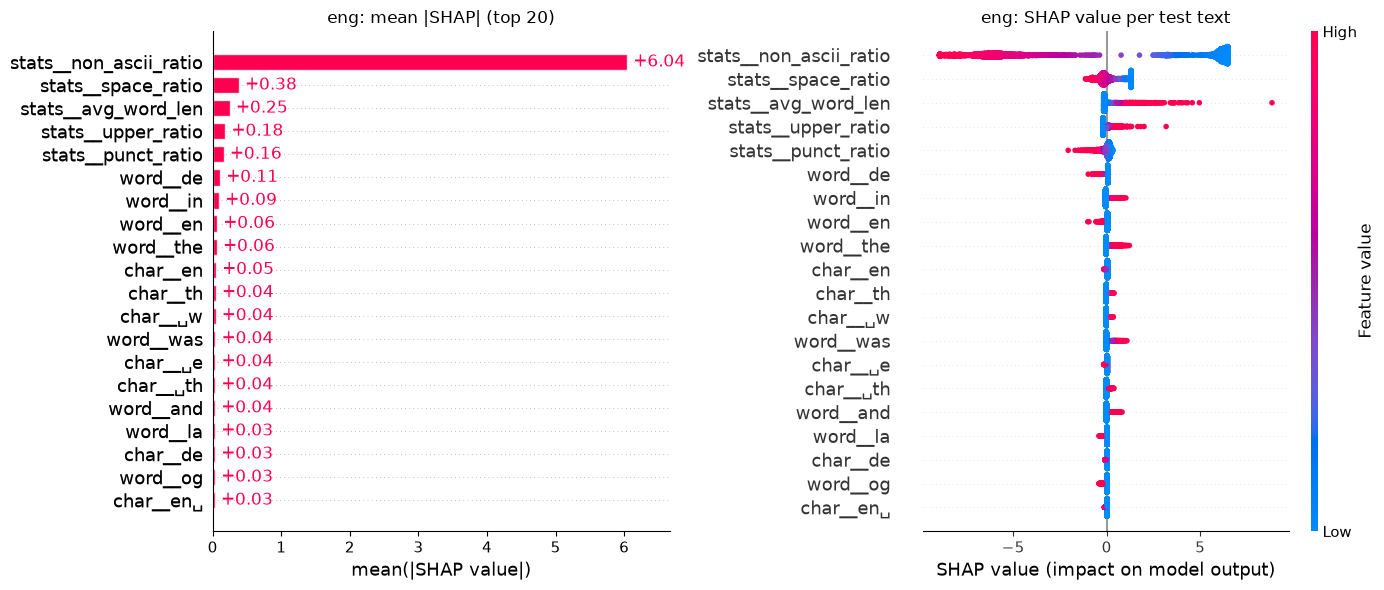

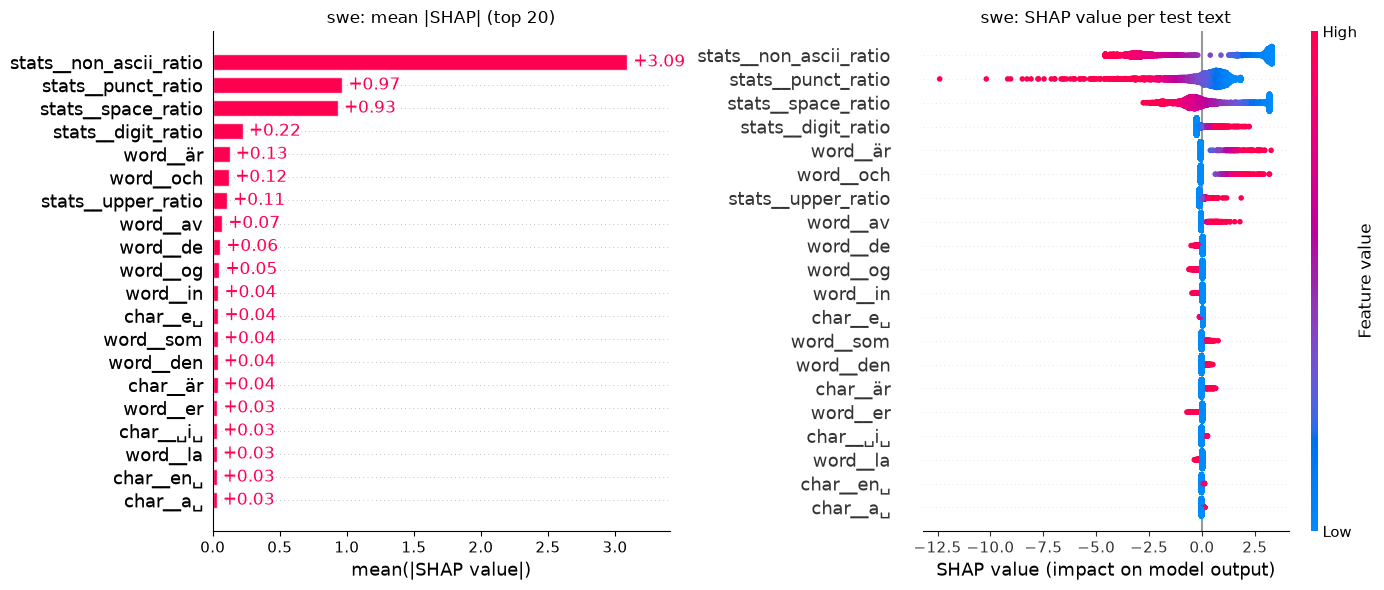

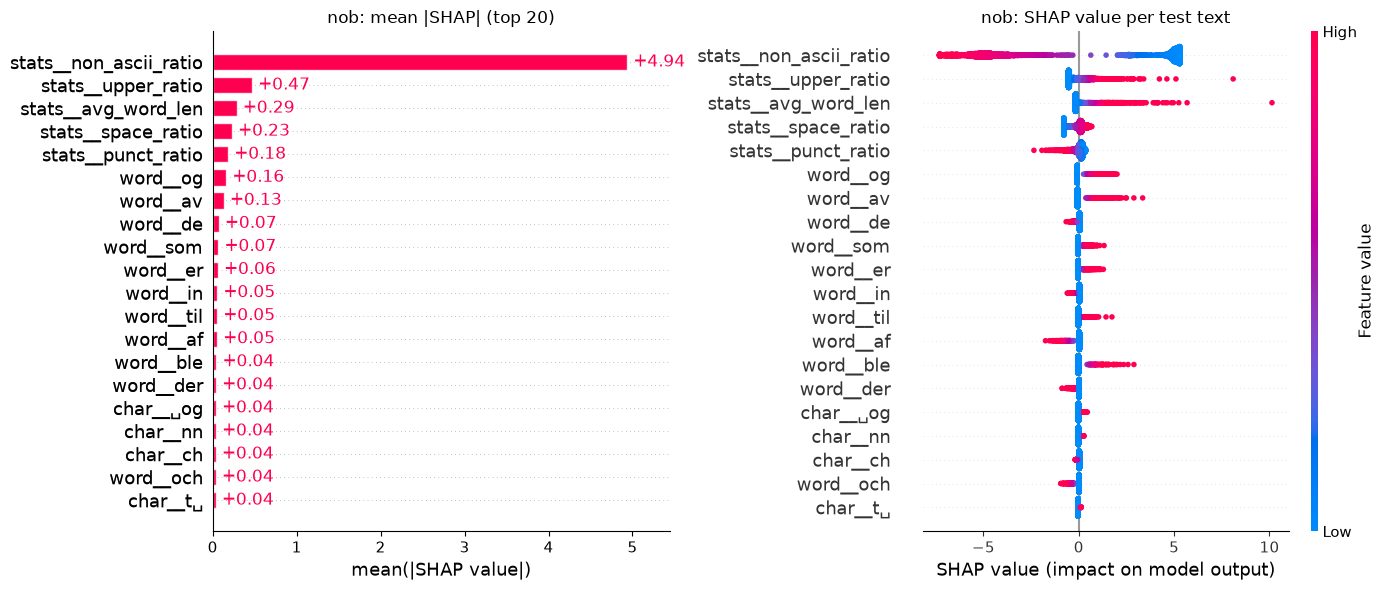

/var/folders/m2/w77shgcn68qbjwzrfhzr5j5h0000gn/T/ipykernel_20959/3385747573.py:35: UserWarning: Glyph 12427 (\N{HIRAGANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/m2/w77shgcn68qbjwzrfhzr5j5h0000gn/T/ipykernel_20959/3385747573.py:35: UserWarning: Glyph 12290 (\N{IDEOGRAPHIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/m2/w77shgcn68qbjwzrfhzr5j5h0000gn/T/ipykernel_20959/3385747573.py:35: UserWarning: Glyph 12414 (\N{HIRAGANA LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/m2/w77shgcn68qbjwzrfhzr5j5h0000gn/T/ipykernel_20959/3385747573.py:35: UserWarning: Glyph 12383 (\N{HIRAGANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/m2/w77shgcn68qbjwzrfhzr5j5h0000gn/T/ipykernel_20959/3385747573.py:35: UserWarning: Glyph 12375 (\N{HIRAGANA LETTER SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/m2/w77shgcn68qbjwzrfhzr5j5h0000gn/T/ipykerne

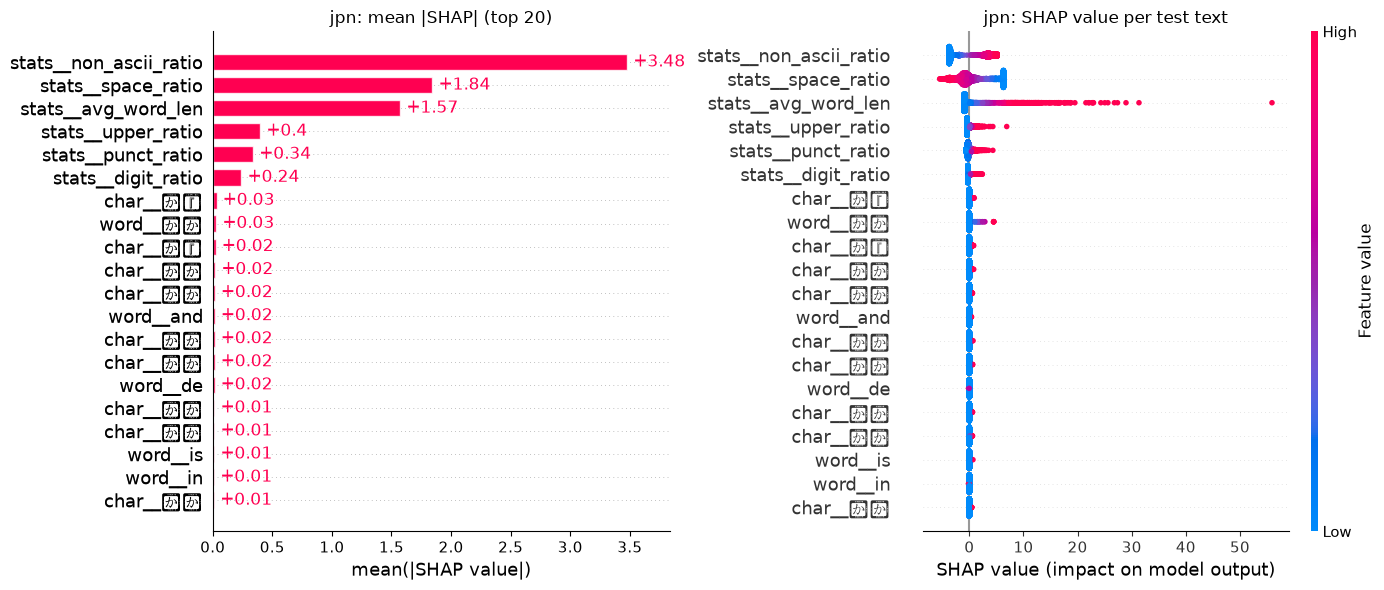

,eng,swe,nob,jpn
1,- stats__non_ascii_ratio,- stats__non_ascii_ratio,- stats__non_ascii_ratio,+ stats__non_ascii_ratio
2,- stats__space_ratio,- stats__punct_ratio,+ stats__upper_ratio,- stats__space_ratio
3,+ stats__avg_word_len,- stats__space_ratio,+ stats__avg_word_len,+ stats__avg_word_len
4,+ stats__upper_ratio,+ stats__digit_ratio,+ stats__space_ratio,+ stats__upper_ratio
5,- stats__punct_ratio,+ word__är,- stats__punct_ratio,+ stats__punct_ratio
6,- word__de,+ word__och,+ word__og,+ stats__digit_ratio
7,+ word__in,+ stats__upper_ratio,+ word__av,+ char__る。
8,- word__en,+ word__av,- word__de,+ word__また
9,+ word__the,- word__de,+ word__som,+ char__た。
10,- char__en,- word__og,+ word__er,+ char__して


In [68]:
# 5.1 step 3: the 20 most important features for English, Swedish, Norwegian and Japanese
# importance = mean |SHAP value| over all test texts for that language's score (logit);
# the bar plots and beeswarm plots are made with shap, using shap.LinearExplainer on the top features
languages_to_inspect = ['eng', 'swe', 'nob', 'jpn']
n_top = 20

def explain_language(language, n_top=n_top):
    k = list(label_encoder.classes_).index(language)
    top = np.argsort(mean_abs_shap.loc[language].to_numpy())[::-1][:n_top]
    # with a linear model each feature's SHAP value only depends on its own weight and mean,
    # so explaining just the top features gives exactly the same values as explaining all of them
    explainer = shap.LinearExplainer((classifier.coef_[k, top], classifier.intercept_[k]),
                                     shap.maskers.Independent(feature_means[top].reshape(1, -1)))
    explanation = explainer(X_test_features[:, top].toarray())
    explanation.feature_names = list(feature_names[top])
    return explanation, top

top_features = {}
for language in languages_to_inspect:
    explanation, top = explain_language(language)
    k = list(label_encoder.classes_).index(language)
    top_features[language] = pd.DataFrame({
        'feature': feature_names[top],
        'mean_abs_shap': mean_abs_shap.loc[language].to_numpy()[top],
        'weight': classifier.coef_[k, top],          # > 0: evidence FOR this language, < 0: evidence AGAINST
    })

    fig = plt.figure(figsize=(14, 6))
    ax1 = fig.add_subplot(1, 2, 1)
    shap.plots.bar(explanation, max_display=n_top, show=False, ax=ax1)
    ax1.set_title(f"{language}: mean |SHAP| (top {n_top})")
    plt.sca(fig.add_subplot(1, 2, 2))
    shap.plots.beeswarm(explanation, max_display=n_top, show=False, plot_size=None)
    plt.title(f"{language}: SHAP value per test text")
    plt.tight_layout()
    plt.show()

# the same top-20 lists side by side ('+' = pushes towards the language, '-' = pushes away from it)
pd.DataFrame({
    language: [f"{'+' if w > 0 else '-'} {f}" for f, w in zip(df['feature'], df['weight'])]
    for language, df in top_features.items()
}, index=range(1, n_top + 1))

In [69]:
# 5.1 step 4: extra features vs vectorizer outputs according to SHAP
# (a) share of the total mean |SHAP| that comes from each feature block, per language
block_importance = mean_abs_shap.T.groupby(feature_block).sum().T
block_share = block_importance.div(block_importance.sum(axis=1), axis=0)
block_share.loc['all languages (mean)'] = block_share.mean()
print("Share of total importance (mean |SHAP|) per feature block:")
display(block_share.loc[languages_to_inspect + ['all languages (mean)']].round(3))

# (b) how important is each extra feature individually? its rank among all features (1 = most important)
ranks = mean_abs_shap.rank(axis=1, ascending=False).astype(int)
stats_columns = list(feature_names[feature_block == 'stats'])
print(f"Rank of each TextStats feature among all {len(feature_names)} features:")
display(ranks.loc[languages_to_inspect, stats_columns])

Share of total importance (mean |SHAP|) per feature block:


,char,stats,word
eng,0.374,0.515,0.110
swe,0.377,0.478,0.145
nob,0.422,0.438,0.140
jpn,0.257,0.705,0.038
all languages (mean),0.327,0.585,0.088


Rank of each TextStats feature among all 100006 features:


,stats__avg_word_len,stats__space_ratio,stats__upper_ratio,stats__digit_ratio,stats__punct_ratio,stats__non_ascii_ratio
eng,3,2,4,623,5,1
swe,71,3,7,4,2,1
nob,3,4,2,85,5,1
jpn,3,2,4,6,5,1


In [70]:
# 5.1 step 5: are the extra features really needed? block ablation
# SHAP shows how much a feature moves the score, not whether the model needs it: if another block carries the
# same information, removing a feature costs nothing. so we retrain without each block (and with each block alone)
# and compare the cross-validated accuracy (same 3 folds as before)
blocks = dict(interp_model.named_steps['vect'].transformer_list)
ablation_settings = {
    'word + char + stats (all)': ['word', 'char', 'stats'],
    'without stats (= best model)': ['word', 'char'],
    'without word': ['char', 'stats'],
    'without char': ['word', 'stats'],
    'stats only': ['stats'],
}

ablation_rows = []
for setting, used_blocks in ablation_settings.items():
    model = clone(interp_model)
    model.named_steps['vect'].transformer_list = [(name, clone(blocks[name])) for name in used_blocks]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        scores = cross_val_score(model, x_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
    ablation_rows.append({'setting': setting, 'cv_accuracy': scores.mean(), 'std': scores.std()})
pd.DataFrame(ablation_rows).set_index('setting').round(4)

,cv_accuracy,std
setting,,
word + char + stats (all),0.9888,0.0002
without stats (= best model),0.9896,0.0004
without word,0.9885,0.0004
without char,0.9697,0.0005
stats only,0.5968,0.0017


#### 5.1 Findings

**Method.** We explain the best configuration from the grid search (word + char_wb tf-idf, L2, C=100, lbfgs) with the 6 `TextStats` features added, so that vectorizer features and extra features can be compared in one model. For a linear model, SHAP values have an exact closed form, `shap = w_kj · (x_ij − mean_j)`: how much feature *j* moves the score of language *k* for text *i*, compared with an average training text. Unlike raw weights, this takes the scale of each feature into account. Feature names come from `get_feature_names_out()` (`word__…`, `char__…`, `stats__…`; `␣` = space). Importance = mean |SHAP| over all test texts.

**Top features (see plots above).**
- **eng / swe / nob:** besides the stats features, the top features are function words and their character n-grams: `the`, `was`, `and`, `th` (eng); `och`, `är`, `av`, `som` (swe); `og`, `av`, `er`, `til`, `ble` (nob). There are also *negative* features, words of related languages: `och` counts against Norwegian, `og`/`er` against Swedish, `de`/`la`/`en` against English.
- **jpn:** character n-grams of hiragana verb endings and particles (`る。`, `た。`, `して`, `され`, `てい`, `した`, `ある`). These separate Japanese from Chinese, which shares the kanji.
- **`stats__non_ascii_ratio` is ranked #1 for all four languages:** negative for eng/swe/nob and positive for jpn. In the beeswarm plots it forms two clusters: Latin-script texts vs everything else. So it separates scripts, not related languages. Every Scandinavian text gets about the same value, so it cannot tell `nob` from `swe`.

**What is more important, extra features or the vectorizer?** The vectorizer, especially character n-grams, even though SHAP gives the extra features the largest share:

| | char | stats | word |
|---|---|---|---|
| share of mean \|SHAP\| (all languages) | 0.33 | 0.58 | 0.09 |

| model (3-fold CV accuracy) | |
|---|---|
| word + char + stats | 0.9888 |
| **word + char (best model, no extra features)** | **0.9896** |
| char + stats (no word) | 0.9885 |
| word + stats (no char) | 0.9697 |
| stats only | 0.5968 |

- **Removing the 6 extra features does not hurt; accuracy goes up slightly.** Removing the char n-grams costs about 2 points, and the stats features alone reach only about 60%.
- **Why SHAP still ranks the stats features highest:** they are dense and standardised, so every text has a large deviation from the average (for example, Latin vs CJK on `non_ascii_ratio`), while each tf-idf n-gram is 0 in most texts. Their information (mostly which script a text uses) is redundant: the character n-grams already encode it.
- **SHAP measures how much a feature moves the prediction, not whether the model needs it.** The ablation shows the second.

---

### 6.1 Ablation Study

Lastly, we want to conduct a small ablation study to investigate how well our model performs under different conditions.

As a first step, choose the two languages for which the classifier worked best.

Next, re-fit the best model six times, each time reducing the **length** of each instance in the training set. To do this, create a custom `TextReducer` class that you can include as a preprocessing step in your pipeline. The class should take a `max_len` argument as a hyperparameter that can be set to train the following models:

- Model 1: `max_len = None` (i.e. no truncation!)
- Model 2: `max_len = 500`
- Model 3: `max_len = 250`
- Model 4: `max_len = 150`
- Model 5: `max_len = 100`
- Model 6: `max_len = 50`

Use average accuracy over the cross validation scores for each model to measure performance for each ablation setting.

📝❓ How does the reduction of training data affect the performance of the classifier? And what could be some possible reasons for this?

In [71]:
# TODO: Ablation study
# 6.1 step 1: choose the two languages for which the classifier worked best (highest F1 on the test set, from 3.3)
from sklearn.metrics import f1_score

per_language_f1 = (pd.Series(f1_score(y_test, y_pred, average=None), index=label_encoder.classes_)
                   .sort_values(ascending=False, kind='stable'))
best_two = list(per_language_f1.index[:2])
print(per_language_f1.head(6).round(4).to_string())
print(f"\nBest two languages: {best_two}")

ara    1.0000
kan    1.0000
heb    0.9975
swe    0.9975
jpn    0.9950
nld    0.9950

Best two languages: ['ara', 'kan']


In [72]:
# 6.1 step 2: TextReducer, a preprocessing step that truncates each text to its first `max_len` characters
from sklearn.base import BaseEstimator, TransformerMixin

class TextReducer(BaseEstimator, TransformerMixin):
    """Truncate every text to its first `max_len` characters (max_len=None: keep the full text).

    Inside a Pipeline, fit() calls fit_transform() on the training texts and predict() calls transform()
    on the texts to predict. So:
    - reduce_at_predict=False: only the training texts are truncated; we predict on full-length texts
      (this isolates the effect of reducing the *training data*, which is what the question asks)
    - reduce_at_predict=True: training and predicted texts are both truncated (short texts at test time too)
    """
    def __init__(self, max_len=None, reduce_at_predict=False):
        self.max_len = max_len
        self.reduce_at_predict = reduce_at_predict

    def _truncate(self, X):
        if self.max_len is None:
            return X
        return [text[:self.max_len] for text in X]

    def fit(self, X, y=None):
        return self

    def fit_transform(self, X, y=None):
        return self._truncate(X)

    def transform(self, X):
        return self._truncate(X) if self.reduce_at_predict else X

In [73]:
# 6.1 step 3: re-fit the best model 6 times with decreasing max_len, measuring the average 5-fold CV accuracy
# runs on the training texts of the chosen languages only; also runs a hard pair (dan / nob) for comparison,
# since two languages with different scripts may be perfectly separable at any length
import warnings
from sklearn.base import clone
from sklearn.model_selection import cross_val_score

max_lens = [None, 500, 250, 150, 100, 50]
language_pairs = {'best two: ' + ' / '.join(best_two): best_two, 'hard pair: dan / nob': ['dan', 'nob']}

ablation_rows = []
for pair_name, languages in language_pairs.items():
    in_pair = np.isin(label_encoder.inverse_transform(y_train), languages)
    x_pair, y_pair = x_train[in_pair], y_train[in_pair]
    for reduce_at_predict in [False, True]:
        for max_len in max_lens:
            model = Pipeline([('reduce', TextReducer(max_len=max_len, reduce_at_predict=reduce_at_predict)),
                              *clone(final_model).steps])
            with warnings.catch_warnings():
                warnings.simplefilter('ignore', FutureWarning)   # 'penalty' deprecation warning
                scores = cross_val_score(model, x_pair, y_pair, cv=5, scoring='accuracy')
            ablation_rows.append({
                'pair': pair_name,
                'truncated': 'train + predict' if reduce_at_predict else 'train only',
                'max_len': 'None' if max_len is None else max_len,
                'texts_truncated': np.mean(x_pair.str.len() > max_len) if max_len else 0.0,
                'cv_accuracy': scores.mean(),
                'std': scores.std(),
            })

ablation_results = pd.DataFrame(ablation_rows)
ablation_results.pivot_table(index='max_len', columns=['pair', 'truncated'], values='cv_accuracy', sort=False).round(4)

pair      best two: ara / kan                 hard pair: dan / nob  \
truncated          train only train + predict           train only   
max_len                                                              
None                   0.9981          0.9981               0.9913   
500                    0.9981          0.9981               0.9919   
250                    0.9981          0.9981               0.9912   
150                    0.9981          0.9981               0.9925   
100                    0.9981          0.9981               0.9894   
50                     0.9981          0.9969               0.9887   

pair                       
truncated train + predict  
max_len                    
None               0.9913  
500                0.9919  
250                0.9906  
150                0.9781  
100                0.9538  
50                 0.9069

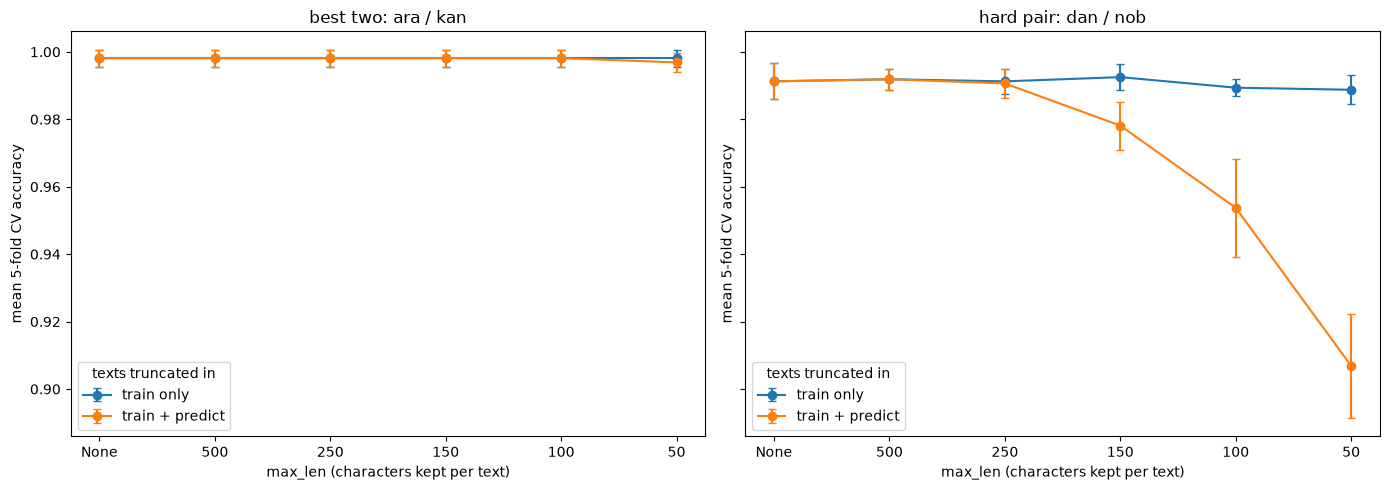

Training text length: min 140, median 299, 90th percentile 714, max 7353


In [74]:
# 6.1 step 4: plot accuracy vs max_len
fig, axes = plt.subplots(1, len(language_pairs), figsize=(14, 5), sharey=True)   # same y-axis, so both pairs are comparable
for ax, pair_name in zip(np.atleast_1d(axes), language_pairs):
    for truncated, group in ablation_results[ablation_results['pair'] == pair_name].groupby('truncated', sort=False):
        ax.errorbar(group['max_len'].astype(str), group['cv_accuracy'], yerr=group['std'], marker='o', capsize=3, label=truncated)
    ax.set_title(pair_name)
    ax.set_xlabel('max_len (characters kept per text)')
    ax.set_ylabel('mean 5-fold CV accuracy')
    ax.legend(title='texts truncated in')
plt.tight_layout()
plt.show()

# how long are the texts in the first place? (how much does each max_len actually remove)
text_lengths = x_train.str.len()
print(f"Training text length: min {text_lengths.min()}, median {text_lengths.median():.0f}, "
      f"90th percentile {text_lengths.quantile(0.9):.0f}, max {text_lengths.max()}")

#### 6.1 Findings

**Setup.** The two best languages on the test set are `ara` and `kan`, both with F1 = 1.000 (cell above). We re-fit the best model with a `TextReducer` step in front of it for `max_len` = None, 500, 250, 150, 100 and 50 characters, and report the mean 5-fold CV accuracy on the training texts of the two languages. Training texts are 140–7353 characters long (median 299), so `max_len=500` shortens about 28% of the texts, while 100 and 50 shorten all of them.

Two variants:
- **train only:** only the training texts are truncated; we predict on full texts. This is what the question asks: less training data.
- **train + predict:** the texts we predict on are truncated too, i.e. the model also has to classify short texts.

Since `ara` and `kan` use different scripts, we also ran a hard pair of closely related languages, `dan` / `nob`, for comparison.

| max_len | ara / kan (train only) | ara / kan (train + predict) | dan / nob (train only) | dan / nob (train + predict) |
|---|---|---|---|---|
| None | 0.9981 | 0.9981 | 0.9913 | 0.9913 |
| 500 | 0.9981 | 0.9981 | 0.9919 | 0.9919 |
| 250 | 0.9981 | 0.9981 | 0.9912 | 0.9906 |
| 150 | 0.9981 | 0.9981 | 0.9925 | 0.9781 |
| 100 | 0.9981 | 0.9981 | 0.9894 | 0.9538 |
| 50 | 0.9981 | 0.9969 | 0.9887 | 0.9069 |

**How does reducing the training data affect performance?**
- **Best two languages (`ara` / `kan`): no effect.** Arabic and Kannada use different scripts, so a single character is enough to tell them apart, and even 50-character texts contain plenty. The accuracy is not quite 1.0 because about 3 of the ~1,600 texts are wrong at every `max_len`, probably noisy or mislabelled texts (not checked).
- **Hard pair (`dan` / `nob`), training texts only truncated: almost no effect either** (0.991 → 0.989 at 50 characters). With about 800 training texts per language, even 50 characters each still give the model about 40,000 characters to learn the distinguishing n-grams from (`og`/`av`, `ble`, `nn`, …).
- **Hard pair, predicted texts also truncated: accuracy drops clearly**, from 0.991 to 0.978 (150), 0.954 (100) and 0.907 (50). A 50-character text has only a few words, and often none of the few function words that separate Danish from Norwegian. Short texts also have higher variance across folds.
- **So, for this task, the amount of text the model sees at prediction time matters much more than the length of the training texts.** How much length matters depends on how similar the languages are: for different scripts it doesn't matter at all, for closely related languages it matters a lot.

#### 6.1 Extension: all 20 languages at once

The task asks for the two best languages, which are by definition the hardest to hurt. Here the same 6 `max_len` settings are run on all 20 languages together, with macro and per-language metrics, to see *which* languages suffer from shorter texts.

In [76]:
# 6.1 extension: the same ablation on all 20 languages at once
# cross_val_predict gives one out-of-fold prediction for every training text (5 folds), so for every max_len we can
# compute accuracy, macro precision / recall / F1 and the F1 of each language
# runtime: 6 max_len x 2 variants x 5 folds = 60 fits on ~16k texts (several minutes, even in parallel)
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score

# l1_ratio=0 is the same L2 model as penalty='l2'; resetting penalty to its default avoids the
# FutureWarning that every parallel worker would otherwise print
all_language_model = clone(final_model)

macro_rows = []
per_language_f1_by_setting = {}
for reduce_at_predict in [False, True]:
    truncated = 'train + predict' if reduce_at_predict else 'train only'
    for max_len in max_lens:
        model = Pipeline([('reduce', TextReducer(max_len=max_len, reduce_at_predict=reduce_at_predict)),
                          *clone(all_language_model).steps])
        cv_pred = cross_val_predict(model, x_train, y_train, cv=5, n_jobs=-1)

        max_len_name = 'None' if max_len is None else max_len
        precision, recall, f1, _ = precision_recall_fscore_support(y_train, cv_pred, average='macro')
        macro_rows.append({'truncated': truncated, 'max_len': max_len_name, 'accuracy': accuracy_score(y_train, cv_pred),
                           'macro_precision': precision, 'macro_recall': recall, 'macro_f1': f1})
        per_language_f1_by_setting[(truncated, max_len_name)] = f1_score(y_train, cv_pred, average=None)

macro_results = pd.DataFrame(macro_rows)
# rows: languages, columns: (truncated, max_len)
per_language_f1_all = pd.DataFrame(per_language_f1_by_setting, index=label_encoder.classes_)
macro_results.round(4)

Python(15379) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15380) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15381) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15382) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15383) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15384) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15385) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15386) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15387) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(15388) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/Users/syongchaiwat/

,truncated,max_len,accuracy,macro_precision,macro_recall,macro_f1
0,train only,None,0.9898,0.9903,0.9898,0.9899
1,train only,500,0.9898,0.9903,0.9898,0.9899
2,train only,250,0.9898,0.9903,0.9898,0.9899
3,train only,150,0.9894,0.9900,0.9894,0.9895
4,train only,100,0.9881,0.9889,0.9881,0.9883
5,train only,50,0.9857,0.9868,0.9857,0.9860
6,train + predict,None,0.9898,0.9903,0.9898,0.9899
7,train + predict,500,0.9899,0.9905,0.9899,0.9900
8,train + predict,250,0.9897,0.9903,0.9897,0.9899
9,train + predict,150,0.9873,0.9879,0.9873,0.9874


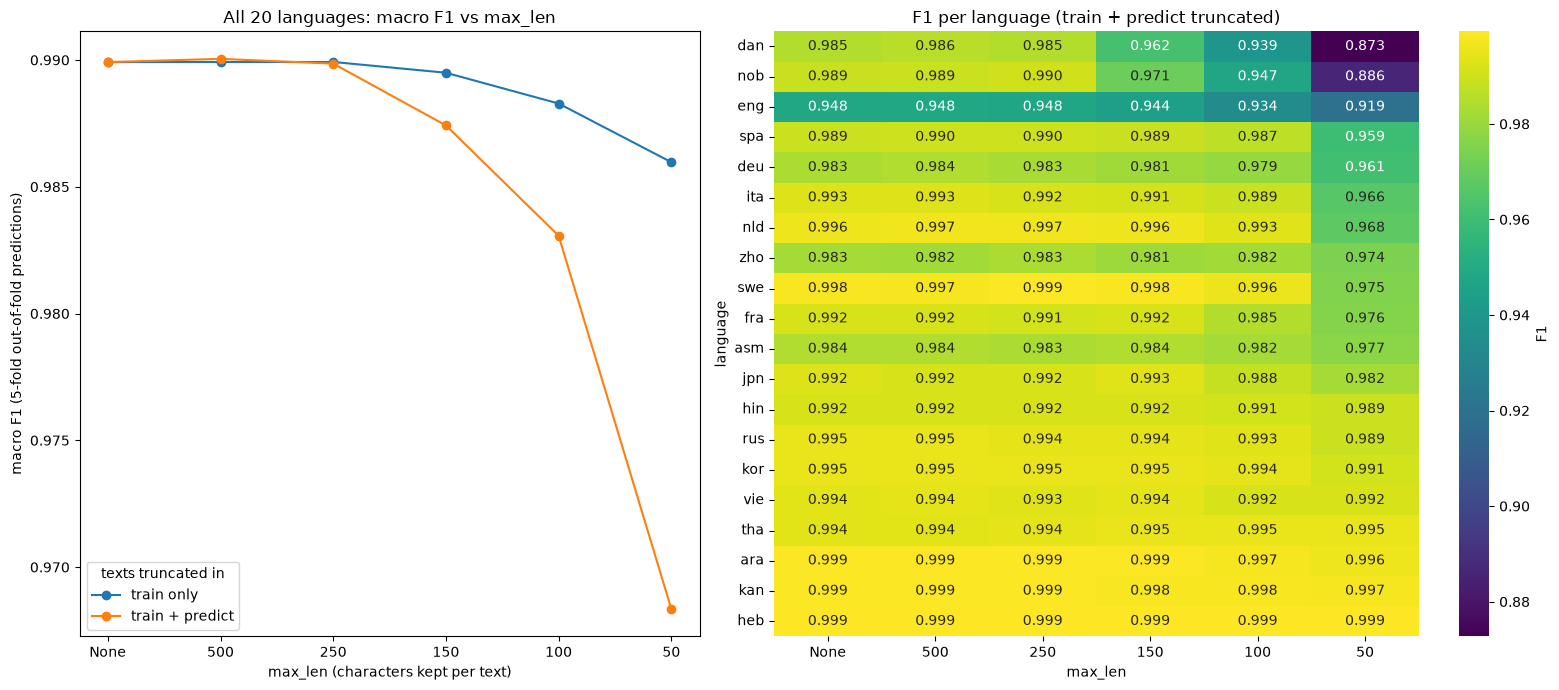

F1 drop from full texts to max_len=50 (largest first):


,train only,train + predict
dan,0.0076,0.1122
nob,0.0044,0.1023
spa,0.0032,0.0299
eng,0.0197,0.0289
nld,0.0076,0.0285
ita,0.0063,0.0263
swe,0.0006,0.0230
deu,0.0081,0.0220
fra,0.0123,0.0162
jpn,0.0019,0.0102


In [77]:
# 6.1 extension: plots
# left: macro F1 vs max_len for both variants; right: F1 of every language when the predicted texts are truncated too
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 1.3]})

for truncated, group in macro_results.groupby('truncated', sort=False):
    ax1.plot(group['max_len'].astype(str), group['macro_f1'], marker='o', label=truncated)
ax1.set_title('All 20 languages: macro F1 vs max_len')
ax1.set_xlabel('max_len (characters kept per text)')
ax1.set_ylabel('macro F1 (5-fold out-of-fold predictions)')
ax1.legend(title='texts truncated in')

f1_short_texts = per_language_f1_all['train + predict']
f1_short_texts = f1_short_texts.sort_values(f1_short_texts.columns[-1])   # languages hurt most by short texts on top
sns.heatmap(f1_short_texts, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label': 'F1'}, ax=ax2)
ax2.set_title('F1 per language (train + predict truncated)')
ax2.set_xlabel('max_len')
ax2.set_ylabel('language')
plt.tight_layout()
plt.show()

# biggest drop in F1 between full texts and 50 characters, per variant
f1_drop = pd.DataFrame({
    truncated: per_language_f1_all[(truncated, 'None')] - per_language_f1_all[(truncated, 50)]
    for truncated in ['train only', 'train + predict']
}).sort_values('train + predict', ascending=False)
print("F1 drop from full texts to max_len=50 (largest first):")
f1_drop.round(4).head(10)

---

📝❓ Write your lab report here addressing all questions in the notebook